# Question 1 — fixed-split forecasting for the next eight years

This notebook compares four forecasting methods for **London overall**, **Inner and Outer London**, and **all 32 boroughs** at monthly, quarterly and annual frequencies.

The formal design follows the group's original rule: **Years 1–6 train the models, Year 7 selects the model and any useful external feature, and Year 8 is tested once after refitting on Years 1–7**. A separate fixed-origin multi-step forecast from the end of Year 6 measures how reliability changes across Years 7–8. Figures are displayed in the notebook; no image or result file is written.


## 1. Data and forecasting rules

The three outcomes are **Inactive**, **Fairly Active** and **Active**. They are forecast together and projected back onto a valid composition, so every point is between 0% and 100% and the three values always add to 100%.

The base model uses only information available at the forecast origin: previous activity composition, the same period one year earlier, a short recent mean, calendar season and a gradual trend. A separate Year 7 experiment studies exactly three interpretable external variables: **population aged 65+**, **adult-population growth**, and **median weekly earnings**.

The variables are tested one at a time with a one-year lag. They are not combined and are not promoted into the official model. Year 8 testing and future eight-year forecasts therefore remain based on activity history alone.


In [1]:
# Load the three prepared panels and the modelling libraries.
from pathlib import Path
import os
import warnings

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
# Load the libraries required for this section.
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
# Load the libraries required for this section.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 2026
TARGETS = ['inactive_rate', 'fairly_active_rate', 'active_rate']
# Select the variables needed for this part of the analysis.
TARGET_LABELS = {'inactive_rate': 'Inactive', 'fairly_active_rate': 'Fairly Active', 'active_rate': 'Active'}
MODELS = ['Naive baseline', 'Ridge Regression', 'Random Forest', 'Gradient Boosting']
MODEL_COLORS = {
    'Naive baseline': '#9E9E9E', 'Ridge Regression': '#4C72B0',
    'Random Forest': '#55A868', 'Gradient Boosting': '#C44E52',
}
LEVELS = ['London', 'Inner/Outer', 'Borough']
# Calculate and store FREQUENCIES for the following analysis step.
FREQUENCIES = ['Monthly', 'Quarterly', 'Annual']

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'question1_outputs').exists() else cwd.parent
DATA_DIR = PROJECT_ROOT / 'question1_outputs' / 'prepared_data'
BOUNDARY_PATH = PROJECT_ROOT / 'extradata' / 'london_borough_boundaries.geojson'
FREQUENCY_CONFIG = {
    'Monthly': {
        'path': DATA_DIR / 'q1_monthly.csv', 'time': 'month_index',
        'date': 'period_start', 'periods_per_year': 12, 'seasonal_lag': 12,
        'recent_window': 3, 'backtest_start': 73, 'future_periods': 96,
    },
    'Quarterly': {
        'path': DATA_DIR / 'q1_quarterly.csv', 'time': 'quarter_index',
        'date': 'quarter_start', 'periods_per_year': 4, 'seasonal_lag': 4,
        'recent_window': 2, 'backtest_start': 25, 'future_periods': 32,
    },
    'Annual': {
        'path': DATA_DIR / 'q1_annual.csv', 'time': 'year',
        'date': None, 'periods_per_year': 1, 'seasonal_lag': 1,
        'recent_window': 1, 'backtest_start': 5, 'future_periods': 8,
    },
}

# Prepare the data used in the next calculation or visualisation.
frequency_frames = {}
for frequency, config in FREQUENCY_CONFIG.items():
    frame = pd.read_csv(config['path'])
    if config['date']:
        frame[config['date']] = pd.to_datetime(frame[config['date']])
    frequency_frames[frequency] = frame

# Calculate and store borough boundaries for the following analysis step.
borough_boundaries = gpd.read_file(BOUNDARY_PATH)[['gss_code', 'name', 'geometry']]

# Derive adult-population growth once per geography-year, then attach it to each frequency.
for frequency, frame in frequency_frames.items():
    population_year = frame[[
        'geography_code', 'year', 'adult_population'
    ]].drop_duplicates(['geography_code', 'year']).sort_values(['geography_code', 'year'])
    population_year['adult_population_growth'] = population_year.groupby(
        'geography_code'
    )['adult_population'].pct_change()
    frequency_frames[frequency] = frame.merge(
        population_year[['geography_code', 'year', 'adult_population_growth']],
        on=['geography_code', 'year'], validate='many_to_one'
    )



### Independent validation

The compact audit below checks the number of geographies and periods, duplicate geography–time keys, missing outcomes and the largest deviation from a 100% composition. These checks are repeated here so forecasting does not depend silently on Notebook 01 having run correctly.


In [2]:
# Build the nine modelling panels and summarise their validity.
LEVEL_FILTERS = {'London': 'London', 'Inner/Outer': 'InnerOuter', 'Borough': 'Borough'}
panels, audit_rows = {}, []

for frequency, frame in frequency_frames.items():
    time_column = FREQUENCY_CONFIG[frequency]['time']
    for level, source_label in LEVEL_FILTERS.items():
        panel = frame.loc[frame['geography_level'].eq(source_label)].copy()
        panel = panel.sort_values(['geography_code', time_column]).reset_index(drop=True)
        panels[(level, frequency)] = panel
        complete_targets = panel[TARGETS].notna().all(axis=1)
        composition_error = (panel.loc[complete_targets, TARGETS].sum(axis=1) - 1).abs().max()
        audit_rows.append({
            'Geography': level, 'Frequency': frequency,
            'Areas': panel['geography_code'].nunique(),
            'Periods': panel[time_column].nunique(),
            'Duplicate keys': panel.duplicated(['geography_code', time_column]).sum(),
            'Rows with missing outcomes': int((~complete_targets).sum()),
            'Maximum sum error': composition_error,
            'Median effective n': panel['effective_n'].median(),
        })

# Define the time split or forecast horizon used for evaluation.
validation_summary = pd.DataFrame(audit_rows)
assert validation_summary['Duplicate keys'].eq(0).all()
assert validation_summary['Maximum sum error'].lt(1e-8).all()
display(validation_summary.round({'Maximum sum error': 8, 'Median effective n': 0}))


,Geography,Frequency,Areas,Periods,Duplicate keys,Rows with missing outcomes,Maximum sum error,Median effective n
0,London,Monthly,1,96,0,0,0.0,746.0
1,Inner/Outer,Monthly,2,96,0,0,0.0,366.0
2,Borough,Monthly,32,96,0,1,0.0,25.0
3,London,Quarterly,1,32,0,0,0.0,2134.0
4,Inner/Outer,Quarterly,2,32,0,0,0.0,1071.0
5,Borough,Quarterly,32,32,0,0,0.0,71.0
6,London,Annual,1,8,0,0,0.0,9163.0
7,Inner/Outer,Annual,2,8,0,0,0.0,4570.0
8,Borough,Annual,32,8,0,0,0.0,295.0


## 2. One shared fixed-split framework

The same functions are used for all nine tasks. Monthly and quarterly models include a one-year seasonal lag; annual models use the previous year. Ridge can extend a gradual trend, whereas Random Forest and Gradient Boosting are flexible but cannot extrapolate beyond patterns seen in training. The Naive baseline repeats the same period from the previous year, or the previous annual value.

Model selection uses only Year 7. After the model family and optional external variable are frozen, the model is refitted on Years 1–7 and evaluated once on Year 8. Annual London validation and testing each contain only one observation, so those results are reported but cannot establish a stable advantage for a complex model.


In [3]:
# Create lagged features and run one fixed-origin recursive forecast.
EXTERNAL_EXPERIMENTS = {
    'Base history only': [],
    'Age: 65+ share': ['population_age_65_plus_rate'],
    'Population: growth': ['adult_population_growth'],
    'Income: weekly earnings': ['median_weekly_earnings_gbp'],
}


# Define project composition once so the same rule is reused consistently.
def project_composition(values):
    """Clip predictions to positive values and rescale every row to sum to one."""
    values = np.clip(np.asarray(values, dtype=float), 1e-6, None)
    return values / values.sum(axis=1, keepdims=True)


def make_supervised(panel, config, external_features=None):
    """Create strictly lagged predictors and remove genuine warm-up rows."""
    external_features = external_features or []
    time_column = config['time']
    result = panel.sort_values(['geography_code', time_column]).copy()
    grouped = result.groupby('geography_code', sort=False)
    feature_columns = []
    for target in TARGETS:
        lag1 = f'{target}_lag1'
        result[lag1] = grouped[target].shift(1)
        feature_columns.append(lag1)
        if config['seasonal_lag'] > 1:
            seasonal = f'{target}_seasonal_lag'
            result[seasonal] = grouped[target].shift(config['seasonal_lag'])
            feature_columns.append(seasonal)
        # Calculate and store recent for the following analysis step.
        recent = f'{target}_recent_mean'
        result[recent] = grouped[target].transform(
            lambda series: series.shift(1).rolling(config['recent_window']).mean()
        )
        feature_columns.append(recent)

    # Context always comes from the corresponding period one year earlier.
    context_lag = config['periods_per_year']
    for feature in external_features:
        lagged = f'{feature}_context_lag'
        result[lagged] = grouped[feature].shift(context_lag)
        feature_columns.append(lagged)

    result['trend_years'] = result[time_column] / config['periods_per_year']
    feature_columns.append('trend_years')
    # Apply the appropriate rule for the available data in this case.
    if config['periods_per_year'] > 1:
        phase = 2 * np.pi * (result[time_column] - 1) / config['periods_per_year']
        result['season_sin'], result['season_cos'] = np.sin(phase), np.cos(phase)
        feature_columns += ['season_sin', 'season_cos']
    result = result.dropna(subset=feature_columns + TARGETS).reset_index(drop=True)
    return result, feature_columns


# Define build model once so the same rule is reused consistently.
def build_model(model_name, numeric_features, training_rows):
    """Return a sample-size-aware pipeline for one fitted model family."""
    transformer = ColumnTransformer([
        ('numeric', StandardScaler(), numeric_features),
        ('geography', OneHotEncoder(handle_unknown='ignore', drop='first'), ['geography_code']),
    ])
    leaf = max(1, int(np.ceil(training_rows * .01)))
    if model_name == 'Ridge Regression':
        estimator = Ridge(alpha=8.0)
    elif model_name == 'Random Forest':
        estimator = RandomForestRegressor(
            n_estimators=120, min_samples_leaf=leaf, max_features=.8,
            random_state=RANDOM_STATE, n_jobs=-1,
        )
    else:
        estimator = MultiOutputRegressor(GradientBoostingRegressor(
            n_estimators=100, learning_rate=.04, max_depth=2,
            min_samples_leaf=leaf, random_state=RANDOM_STATE,
        ))
    # Return the completed result to the calling analysis step.
    return Pipeline([('prepare', transformer), ('model', estimator)])


# Define weighted tv once so the same rule is reused consistently.
def weighted_tv(actual, predicted, weights):
    """Calculate precision-weighted total variation for three-part outcomes."""
    row_error = .5 * np.abs(np.asarray(actual) - np.asarray(predicted)).sum(axis=1)
    return np.average(row_error, weights=np.asarray(weights)), row_error


def future_feature_row(code_value, history, context, next_time, config,
                       numeric_features, external_features):
    """Create one future row using predicted activity and last-known context."""
    row = {'geography_code': code_value, 'trend_years': next_time / config['periods_per_year']}
    for position, target in enumerate(TARGETS):
        series = history[:, position]
        row[f'{target}_lag1'] = series[-1]
        if config['seasonal_lag'] > 1:
            row[f'{target}_seasonal_lag'] = series[-config['seasonal_lag']]
        row[f'{target}_recent_mean'] = series[-config['recent_window']:].mean()
    # Repeat the same calculation across the required groups or settings.
    for feature in external_features:
        row[f'{feature}_context_lag'] = context[feature]
    if config['periods_per_year'] > 1:
        phase = 2 * np.pi * (next_time - 1) / config['periods_per_year']
        row['season_sin'], row['season_cos'] = np.sin(phase), np.cos(phase)
    return pd.DataFrame([row])[numeric_features + ['geography_code']]


# Define recursive forecast once so the same rule is reused consistently.
def recursive_forecast(panel, config, model_name, external_features=None, horizon=None,
                       excluded_features=None):
    """Fit one recursive forecast, optionally omitting named predictors for ablation."""
    external_features = external_features or []
    excluded_features = set(excluded_features or [])
    supervised, numeric_features = make_supervised(panel, config, external_features)
    numeric_features = [feature for feature in numeric_features if feature not in excluded_features]
    horizon = horizon or config['future_periods']
    model = None
    if model_name != 'Naive baseline':
        weights = np.clip(
            supervised['effective_n'], supervised['effective_n'].quantile(.05),
            supervised['effective_n'].quantile(.95),
        )
        weights = weights / weights.mean()
        model = build_model(model_name, numeric_features, len(supervised))
        model.fit(
            supervised[numeric_features + ['geography_code']], supervised[TARGETS],
            model__sample_weight=weights,
        )

    # Select the variables needed for this part of the analysis.
    time_column = config['time']
    last_time = int(panel[time_column].max())
    rows = []
    for code_value, group in panel.groupby('geography_code', sort=False):
        group = group.sort_values(time_column)
        history = group[TARGETS].to_numpy().copy()
        context = {feature: group[feature].dropna().iloc[-1] for feature in external_features}
        geography_name = group['geography_name'].iloc[0]
        for step in range(1, horizon + 1):
            next_time = last_time + step
            if model_name == 'Naive baseline':
                lag = config['seasonal_lag'] if config['seasonal_lag'] > 1 else 1
                prediction = history[-lag].reshape(1, -1)
            else:
                features = future_feature_row(
                    code_value, history, context, next_time, config,
                    numeric_features, external_features,
                )
                prediction = model.predict(features)
            # Calculate and store prediction for the following analysis step.
            prediction = project_composition(prediction)[0]
            history = np.vstack([history, prediction])
            rows.append({
                'geography_code': code_value, 'geography_name': geography_name,
                'future_step': step, time_column: next_time,
                **{f'predicted_{target}': prediction[i] for i, target in enumerate(TARGETS)},
            })
    # Return the completed result to the calling analysis step.
    return pd.DataFrame(rows)


# Define score forecast once so the same rule is reused consistently.
def score_forecast(predicted, actual, config):
    """Join a forecast to observed outcomes and return row and period errors."""
    time_column = config['time']
    matched = predicted.merge(
        actual[['geography_code', time_column, 'effective_n', *TARGETS]],
        on=['geography_code', time_column], validate='one_to_one',
    )
    values = matched[[f'predicted_{target}' for target in TARGETS]].to_numpy()
    # Calculate and store  , matched['row tv'] for the following analysis step.
    _, matched['row_tv'] = weighted_tv(matched[TARGETS], values, matched['effective_n'])
    period_scores = matched.groupby(time_column).apply(
        lambda frame: np.average(frame['row_tv'], weights=frame['effective_n']),
        include_groups=False,
    )
    return matched, period_scores


### Fixed validation, three external variables and untouched test

For each task, the four base models forecast all of Year 7 recursively from the end of Year 6. With the selected family held fixed, age, population and income are then tested separately.

This is diagnostic only. Regardless of the Year 7 result, the selected base family is refitted without external variables on Years 1–7 and tested once on Year 8. Future eight-year forecasts also remain base models. The notebook therefore compares the three candidates without allowing exploratory feature selection to alter the formal result.


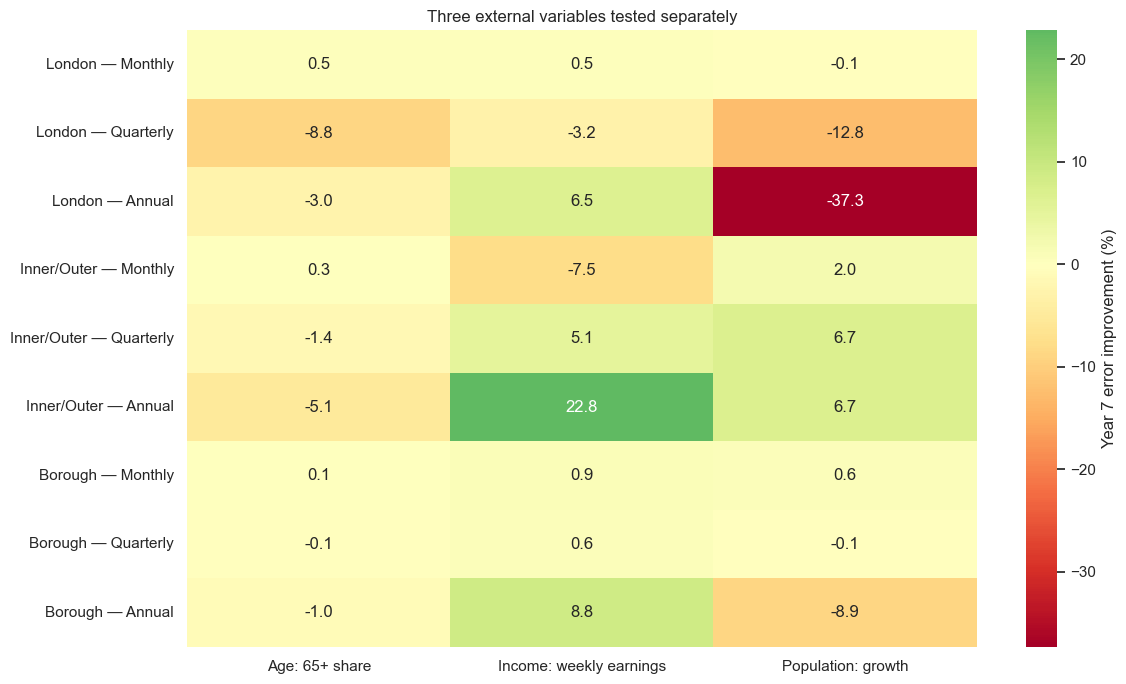

,External variable,Mean improvement (%),Median improvement (%),Tasks improved,Tasks improved by at least 2%
1,Income: weekly earnings,3.8,0.9,7,4
0,Age: 65+ share,-2.1,-1.0,3,0
2,Population: growth,-4.8,-0.1,4,3


In [4]:
# Run the fixed 6/1/1 design, then refit all four families for future disagreement.
validation_parts, model_rows, external_rows = [], [], []
test_parts, test_rows, future_parts, calibration_parts = [], [], [], []
selection_rows, task_choices = [], {}

for level in LEVELS:
    for frequency in FREQUENCIES:
        panel, config = panels[(level, frequency)], FREQUENCY_CONFIG[frequency]
        periods = config['periods_per_year']
        train_6 = panel.loc[panel['year'].le(6)].copy()
        validation_actual = panel.loc[panel['year'].eq(7)].copy()
        train_7 = panel.loc[panel['year'].le(7)].copy()
        test_actual = panel.loc[panel['year'].eq(8)].copy()

        # Stage 1: compare the four model families using only base history.
        family_scores = []
        family_predictions = {}
        for model_name in MODELS:
            predicted = recursive_forecast(train_6, config, model_name, [], periods)
            matched, period_scores = score_forecast(predicted, validation_actual, config)
            mean_error = np.average(matched['row_tv'], weights=matched['effective_n'])
            se = period_scores.std(ddof=1) / np.sqrt(len(period_scores)) if len(period_scores) > 1 else 0.0
            family_scores.append({'model': model_name, 'mean': mean_error, 'se': se})
            family_predictions[model_name] = matched
        # Collect the results in a compact form for comparison.
        family_table = pd.DataFrame(family_scores)
        best_error = family_table['mean'].min()
        eligible = set(family_table.loc[family_table['mean'].le(best_error * 1.02), 'model'])
        selected_model = next(model for model in MODELS if model in eligible)
        family_table['selected'] = family_table['model'].eq(selected_model)
        family_table['geographic_level'], family_table['frequency'] = level, frequency
        model_rows.append(family_table)

        # Stage 2: test three external variables one at a time with the selected family.
        experiment_predictions = {}
        experiment_scores = []
        for design, external_features in EXTERNAL_EXPERIMENTS.items():
            predicted = recursive_forecast(
                train_6, config, selected_model, external_features, periods
            )
            matched, _ = score_forecast(predicted, validation_actual, config)
            error = np.average(matched['row_tv'], weights=matched['effective_n'])
            experiment_scores.append({'design': design, 'validation_tv': error})
            experiment_predictions[design] = matched
        # Collect the results in a compact form for comparison.
        experiment_table = pd.DataFrame(experiment_scores)
        base_error = experiment_table.loc[
            experiment_table['design'].eq('Base history only'), 'validation_tv'
        ].iloc[0]
        experiment_table['improvement_pct'] = (
            1 - experiment_table['validation_tv'] / base_error
        ) * 100
        # The official specification remains base-only; singles are compared descriptively.
        selected_design = 'Base history only'
        selected_external = []
        selected_improvement = 0.0
        experiment_table['selected'] = False
        experiment_table['geographic_level'] = level
        experiment_table['frequency'] = frequency
        external_rows.append(experiment_table)

        validation_selected = experiment_predictions[selected_design].copy()
        # Calculate and store validation selected['model'] for the following analysis step.
        validation_selected['model'] = selected_model
        validation_selected['geographic_level'] = level
        validation_selected['frequency'] = frequency
        validation_parts.append(validation_selected)

        # Stage 3: refit Years 1–7 and touch Year 8 once.
        test_forecast = recursive_forecast(
            train_7, config, selected_model, selected_external, periods
        )
        test_matched, _ = score_forecast(test_forecast, test_actual, config)
        test_error = np.average(test_matched['row_tv'], weights=test_matched['effective_n'])
        test_matched['model'], test_matched['geographic_level'], test_matched['frequency'] = (
            selected_model, level, frequency
        )
        # Apply the next transformation to the prepared analysis object.
        test_parts.append(test_matched)
        test_rows.append({
            'Geography': level, 'Frequency': frequency, 'Selected model': selected_model,
            'External design': selected_design,
            'Validation improvement (%)': selected_improvement, 'Test TV': test_error,
        })

        # Apply the next transformation to the prepared analysis object.
        selection_rows.append({
            'Geography': level, 'Frequency': frequency, 'Selected model': selected_model,
            'External design': selected_design,
            'Validation improvement (%)': selected_improvement,
        })
        task_choices[(level, frequency)] = {
            'model': selected_model, 'design': selected_design,
            'external_features': selected_external,
        }

        # Refit all eight years for future paths; use the selected context design for fair disagreement.
        for model_name in MODELS:
            future = recursive_forecast(
                panel, config, model_name, selected_external, config['future_periods']
            )
            future['model'], future['geographic_level'], future['frequency'] = (
                model_name, level, frequency
            )
            future_parts.append(future)

# Fit the model using the specification defined for this comparison.
model_summary = pd.concat(model_rows, ignore_index=True)
external_summary = pd.concat(external_rows, ignore_index=True)
validation_predictions = pd.concat(validation_parts, ignore_index=True)
test_predictions = pd.concat(test_parts, ignore_index=True)
test_summary = pd.DataFrame(test_rows)
selection_table = pd.DataFrame(selection_rows)
future_forecasts = pd.concat(future_parts, ignore_index=True)

# Use the two frozen one-year forecasts only to calibrate indicative future bands.
calibration_predictions = pd.concat([validation_predictions, test_predictions], ignore_index=True)
selected_future_parts = []
for _, choice in selection_table.iterrows():
    level, frequency, selected = choice['Geography'], choice['Frequency'], choice['Selected model']
    historical = calibration_predictions.loc[
        calibration_predictions['geographic_level'].eq(level)
        & calibration_predictions['frequency'].eq(frequency)
    ]
    future = future_forecasts.loc[
        future_forecasts['geographic_level'].eq(level)
        & future_forecasts['frequency'].eq(frequency)
        & future_forecasts['model'].eq(selected)
    ].copy()
    # Calculate and store periods per year for the following analysis step.
    periods_per_year = FREQUENCY_CONFIG[frequency]['periods_per_year']
    widening = np.sqrt(1 + (future['future_step'] - 1) / periods_per_year).clip(upper=np.sqrt(8))
    for target in TARGETS:
        residual = historical[target] - historical[f'predicted_{target}']
        low_error, high_error = residual.quantile([.10, .90])
        future[f'lower_{target}'] = np.clip(
            future[f'predicted_{target}'] + widening * low_error, 0, 1
        )
        future[f'upper_{target}'] = np.clip(
            future[f'predicted_{target}'] + widening * high_error, 0, 1
        )
    # Apply the next transformation to the prepared analysis object.
    selected_future_parts.append(future)
# Calculate and store selected forecasts for the following analysis step.
selected_forecasts = pd.concat(selected_future_parts, ignore_index=True)

# Compare the final age, population and income candidates without combinations.
single_plot = external_summary.loc[
    ~external_summary['design'].eq('Base history only')
].copy()
single_plot['Task'] = single_plot['geographic_level'] + ' — ' + single_plot['frequency']
single_matrix = single_plot.pivot(
    index='Task', columns='design', values='improvement_pct'
).reindex([f'{level} — {frequency}' for level in LEVELS for frequency in FREQUENCIES])

# Build the figure that presents the comparison clearly.
fig, axis = plt.subplots(figsize=(12, 7))
sns.heatmap(single_matrix, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
            cbar_kws={'label': 'Year 7 error improvement (%)'}, ax=axis)
axis.set(title='Three external variables tested separately', xlabel='', ylabel='')
fig.tight_layout()
plt.show()

# Calculate and store single overall for the following analysis step.
single_overall = single_plot.groupby('design', as_index=False).agg(
    mean_improvement_pct=('improvement_pct', 'mean'),
    median_improvement_pct=('improvement_pct', 'median'),
    tasks_improving=('improvement_pct', lambda values: int((values > 0).sum())),
    tasks_improving_2pct=('improvement_pct', lambda values: int((values >= 2).sum())),
).sort_values('mean_improvement_pct', ascending=False)
display(single_overall.rename(columns={
    'design': 'External variable',
    'mean_improvement_pct': 'Mean improvement (%)',
    'median_improvement_pct': 'Median improvement (%)',
    'tasks_improving': 'Tasks improved',
    'tasks_improving_2pct': 'Tasks improved by at least 2%',
}).round(1))


## 3. London overall

The first figure compares the four base models on the fixed Year 7 validation block. Error bars describe variation within that block where monthly or quarterly observations exist; annual validation contains only one point. The selected specification is then refitted through Year 7 and evaluated on Year 8 before the future forecast is produced.


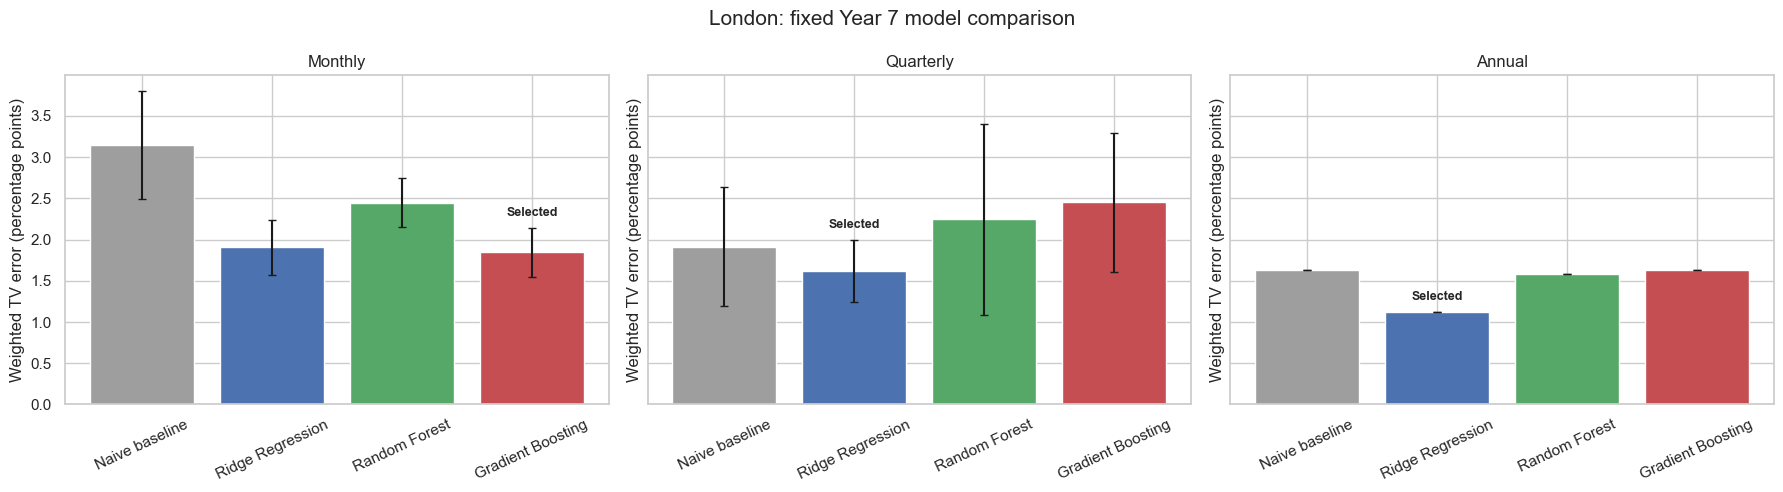

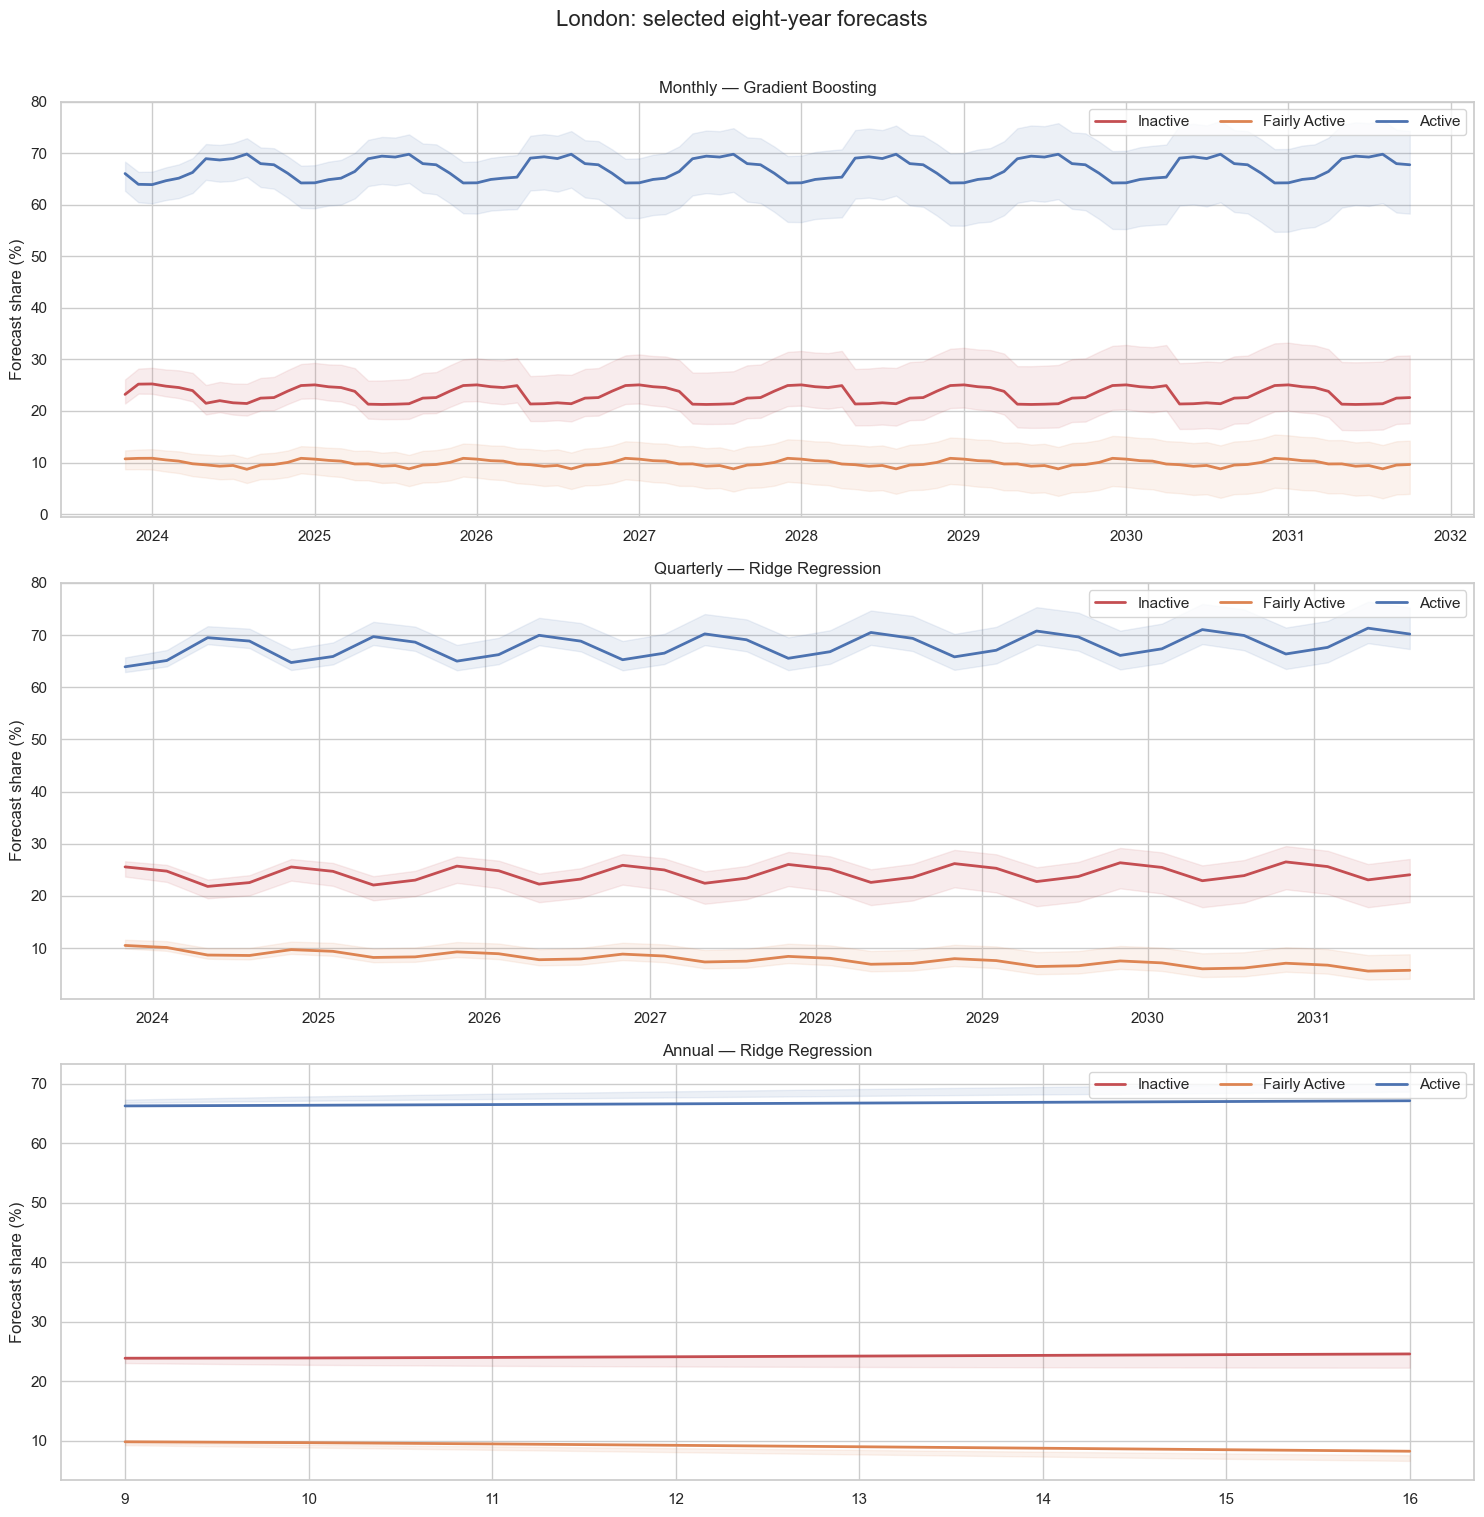

,frequency,model,Inactive,Fairly Active,Active
135,Annual,Ridge Regression,24.6,8.3,67.1
127,Quarterly,Ridge Regression,24.1,5.7,70.2
95,Monthly,Gradient Boosting,22.6,9.6,67.8


In [5]:
# Compare London models and plot the selected eight-year compositions.
def plot_model_comparison(level):
    """Show the four historical model errors for each frequency."""
    local = model_summary.loc[model_summary['geographic_level'].eq(level)].copy()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for axis, frequency in zip(axes, FREQUENCIES):
        subset = local.loc[local['frequency'].eq(frequency)].set_index('model').reindex(MODELS).reset_index()
        colors = [MODEL_COLORS[name] for name in subset['model']]
        axis.bar(subset['model'], subset['mean'] * 100, yerr=subset['se'] * 100,
                 color=colors, capsize=3)
        chosen = subset.loc[subset['selected']].iloc[0]
        axis.text(chosen.name, chosen['mean'] * 100 + chosen['se'] * 100 + .15,
                  'Selected', ha='center', fontsize=9, fontweight='bold')
        # Calculate and store axis.set(title for the following analysis step.
        axis.set(title=frequency, xlabel='', ylabel='Weighted TV error (percentage points)')
        axis.tick_params(axis='x', rotation=25)
    # Create or format the figure for this comparison.
    fig.suptitle(f'{level}: fixed Year 7 model comparison', fontsize=15)
    fig.tight_layout()
    plt.show()


# Define future axis values once so the same rule is reused consistently.
def future_axis_values(frame, frequency):
    """Return readable horizontal values for monthly, quarterly or annual forecasts."""
    config = FREQUENCY_CONFIG[frequency]
    if frequency == 'Monthly':
        start = panels[('London', frequency)][config['date']].max()
        return pd.DatetimeIndex([start + pd.DateOffset(months=int(step)) for step in frame['future_step']])
    if frequency == 'Quarterly':
        start = panels[('London', frequency)][config['date']].max()
        return pd.DatetimeIndex([start + pd.DateOffset(months=3 * int(step)) for step in frame['future_step']])
    # Return the completed result to the calling analysis step.
    return frame[config['time']]


# Apply the next transformation to the prepared analysis object.
plot_model_comparison('London')
fig, axes = plt.subplots(3, 1, figsize=(15, 15))
for axis, frequency in zip(axes, FREQUENCIES):
    future = selected_forecasts.loc[
        selected_forecasts['geographic_level'].eq('London')
        & selected_forecasts['frequency'].eq(frequency)
    ].sort_values('future_step')
    x = future_axis_values(future, frequency)
    for target, color in zip(TARGETS, ['#C44E52', '#DD8452', '#4C72B0']):
        axis.plot(x, future[f'predicted_{target}'] * 100, color=color, linewidth=2,
                  label=TARGET_LABELS[target])
        axis.fill_between(x, future[f'lower_{target}'] * 100,
                          future[f'upper_{target}'] * 100, color=color, alpha=.10)
    # Calculate and store selected for the following analysis step.
    selected = selection_table.query("Geography == 'London' and Frequency == @frequency")['Selected model'].iloc[0]
    axis.set(title=f'{frequency} — {selected}', xlabel='', ylabel='Forecast share (%)')
    axis.legend(ncol=3)
# Create or format the figure for this comparison.
fig.suptitle('London: selected eight-year forecasts', fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

london_endpoints = selected_forecasts.loc[
    selected_forecasts['geographic_level'].eq('London')
].sort_values('future_step').groupby('frequency').tail(1)
# Display the finished visual or summary for interpretation.
display(london_endpoints[['frequency', 'model', *[f'predicted_{target}' for target in TARGETS]]]
        .rename(columns={f'predicted_{target}': TARGET_LABELS[target] for target in TARGETS})
        .assign(**{label: lambda frame, label=label: frame[label] * 100 for label in TARGET_LABELS.values()})
        .round(1))


## 4. Inner and Outer London

The same four-model comparison is repeated without changing the model definitions. Future charts focus on Active because it makes the Inner–Outer difference easiest to read; the endpoint table retains all three predicted states. Separate lines are predictions for the two areas, not confidence bounds around one London value.


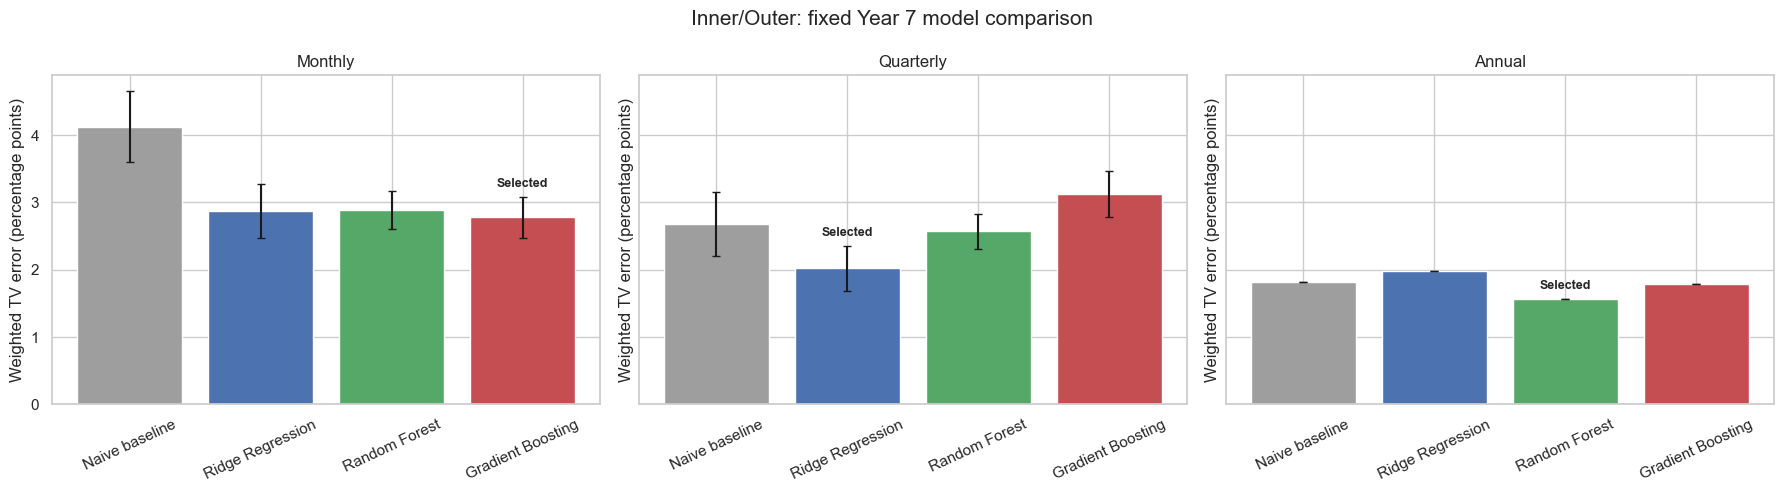

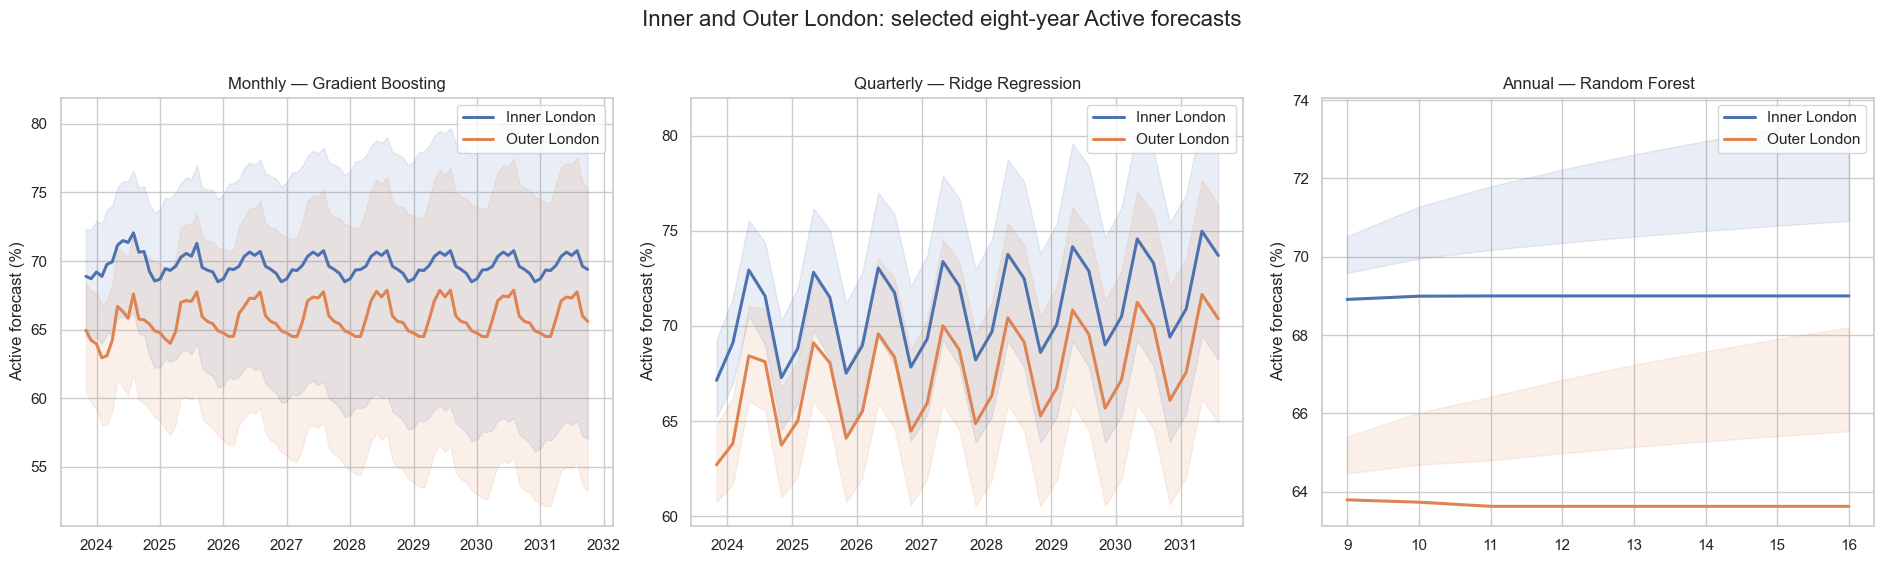

,frequency,geography_name,model,Inactive,Fairly Active,Active
399,Annual,Inner London,Random Forest,21.2,9.8,69.0
407,Annual,Outer London,Random Forest,25.6,10.7,63.6
391,Quarterly,Outer London,Ridge Regression,24.6,5.0,70.4
359,Quarterly,Inner London,Ridge Regression,22.1,4.2,73.7
231,Monthly,Inner London,Gradient Boosting,20.5,10.1,69.4
327,Monthly,Outer London,Gradient Boosting,23.6,10.8,65.6


In [6]:
# Compare Inner/Outer models and show the future Active paths.
plot_model_comparison('Inner/Outer')
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for axis, frequency in zip(axes, FREQUENCIES):
    future = selected_forecasts.loc[
        selected_forecasts['geographic_level'].eq('Inner/Outer')
        & selected_forecasts['frequency'].eq(frequency)
    ].copy()
    for geography_name, color in [('Inner London', '#4C72B0'), ('Outer London', '#DD8452')]:
        line = future.loc[future['geography_name'].eq(geography_name)].sort_values('future_step')
        x = future_axis_values(line, frequency)
        axis.plot(x, line['predicted_active_rate'] * 100, marker=None,
                  linewidth=2.2, color=color, label=geography_name)
        axis.fill_between(x, line['lower_active_rate'] * 100,
                          line['upper_active_rate'] * 100, color=color, alpha=.12)
    # Calculate and store selected for the following analysis step.
    selected = selection_table.query("Geography == 'Inner/Outer' and Frequency == @frequency")['Selected model'].iloc[0]
    axis.set(title=f'{frequency} — {selected}', xlabel='', ylabel='Active forecast (%)')
    axis.legend()
# Create or format the figure for this comparison.
fig.suptitle('Inner and Outer London: selected eight-year Active forecasts', fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

inner_outer_endpoints = selected_forecasts.loc[
    selected_forecasts['geographic_level'].eq('Inner/Outer')
].sort_values('future_step').groupby(
    ['frequency', 'geography_name']
).tail(1)
# Display the finished visual or summary for interpretation.
display(inner_outer_endpoints[[
    'frequency', 'geography_name', 'model',
    *[f'predicted_{target}' for target in TARGETS],
]].rename(columns={f'predicted_{target}': TARGET_LABELS[target] for target in TARGETS})
  .assign(**{label: lambda frame, label=label: frame[label] * 100 for label in TARGET_LABELS.values()})
  .round(1))


## 5. London boroughs

The borough models pool all 32 areas while retaining borough identity. This gives the machine-learning methods substantially more training observations than the London annual task.

For readability, future monthly and quarterly predictions are averaged into eight forecast years. Each heatmap still comes from its own monthly, quarterly or annual model; no frequency is substituted for another. The map uses the final year averaged from the selected quarterly model, which is adopted later as the primary reporting frequency.


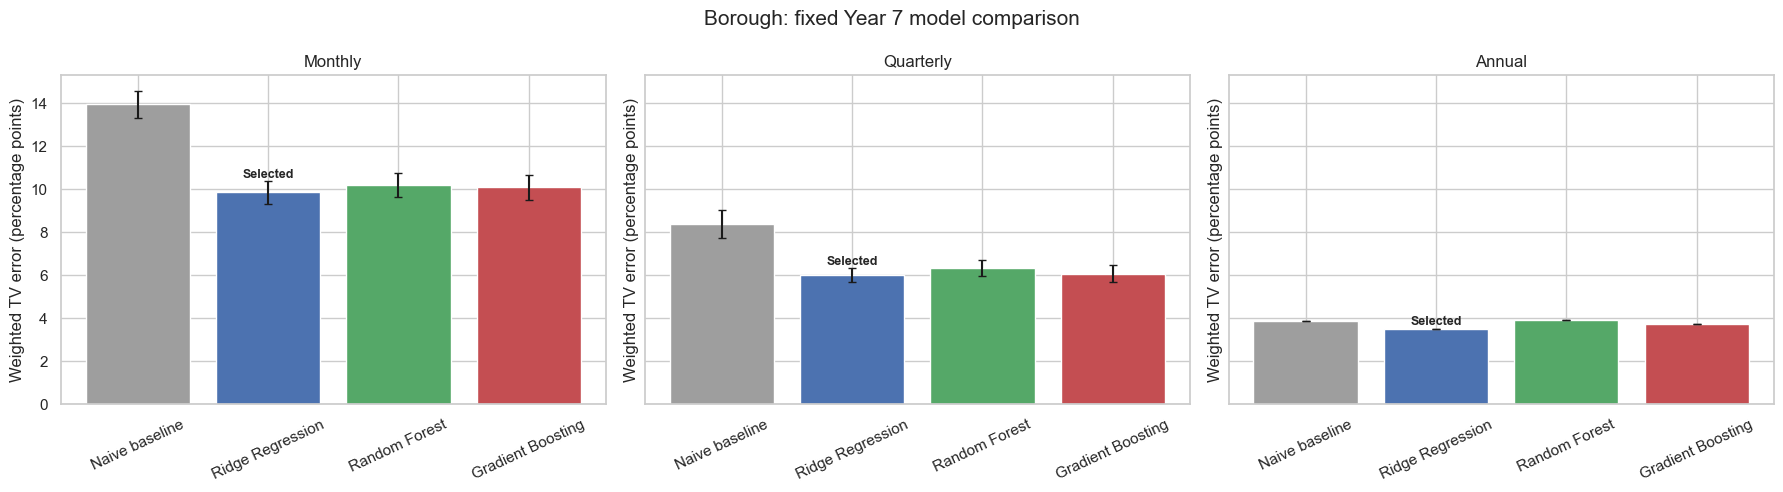

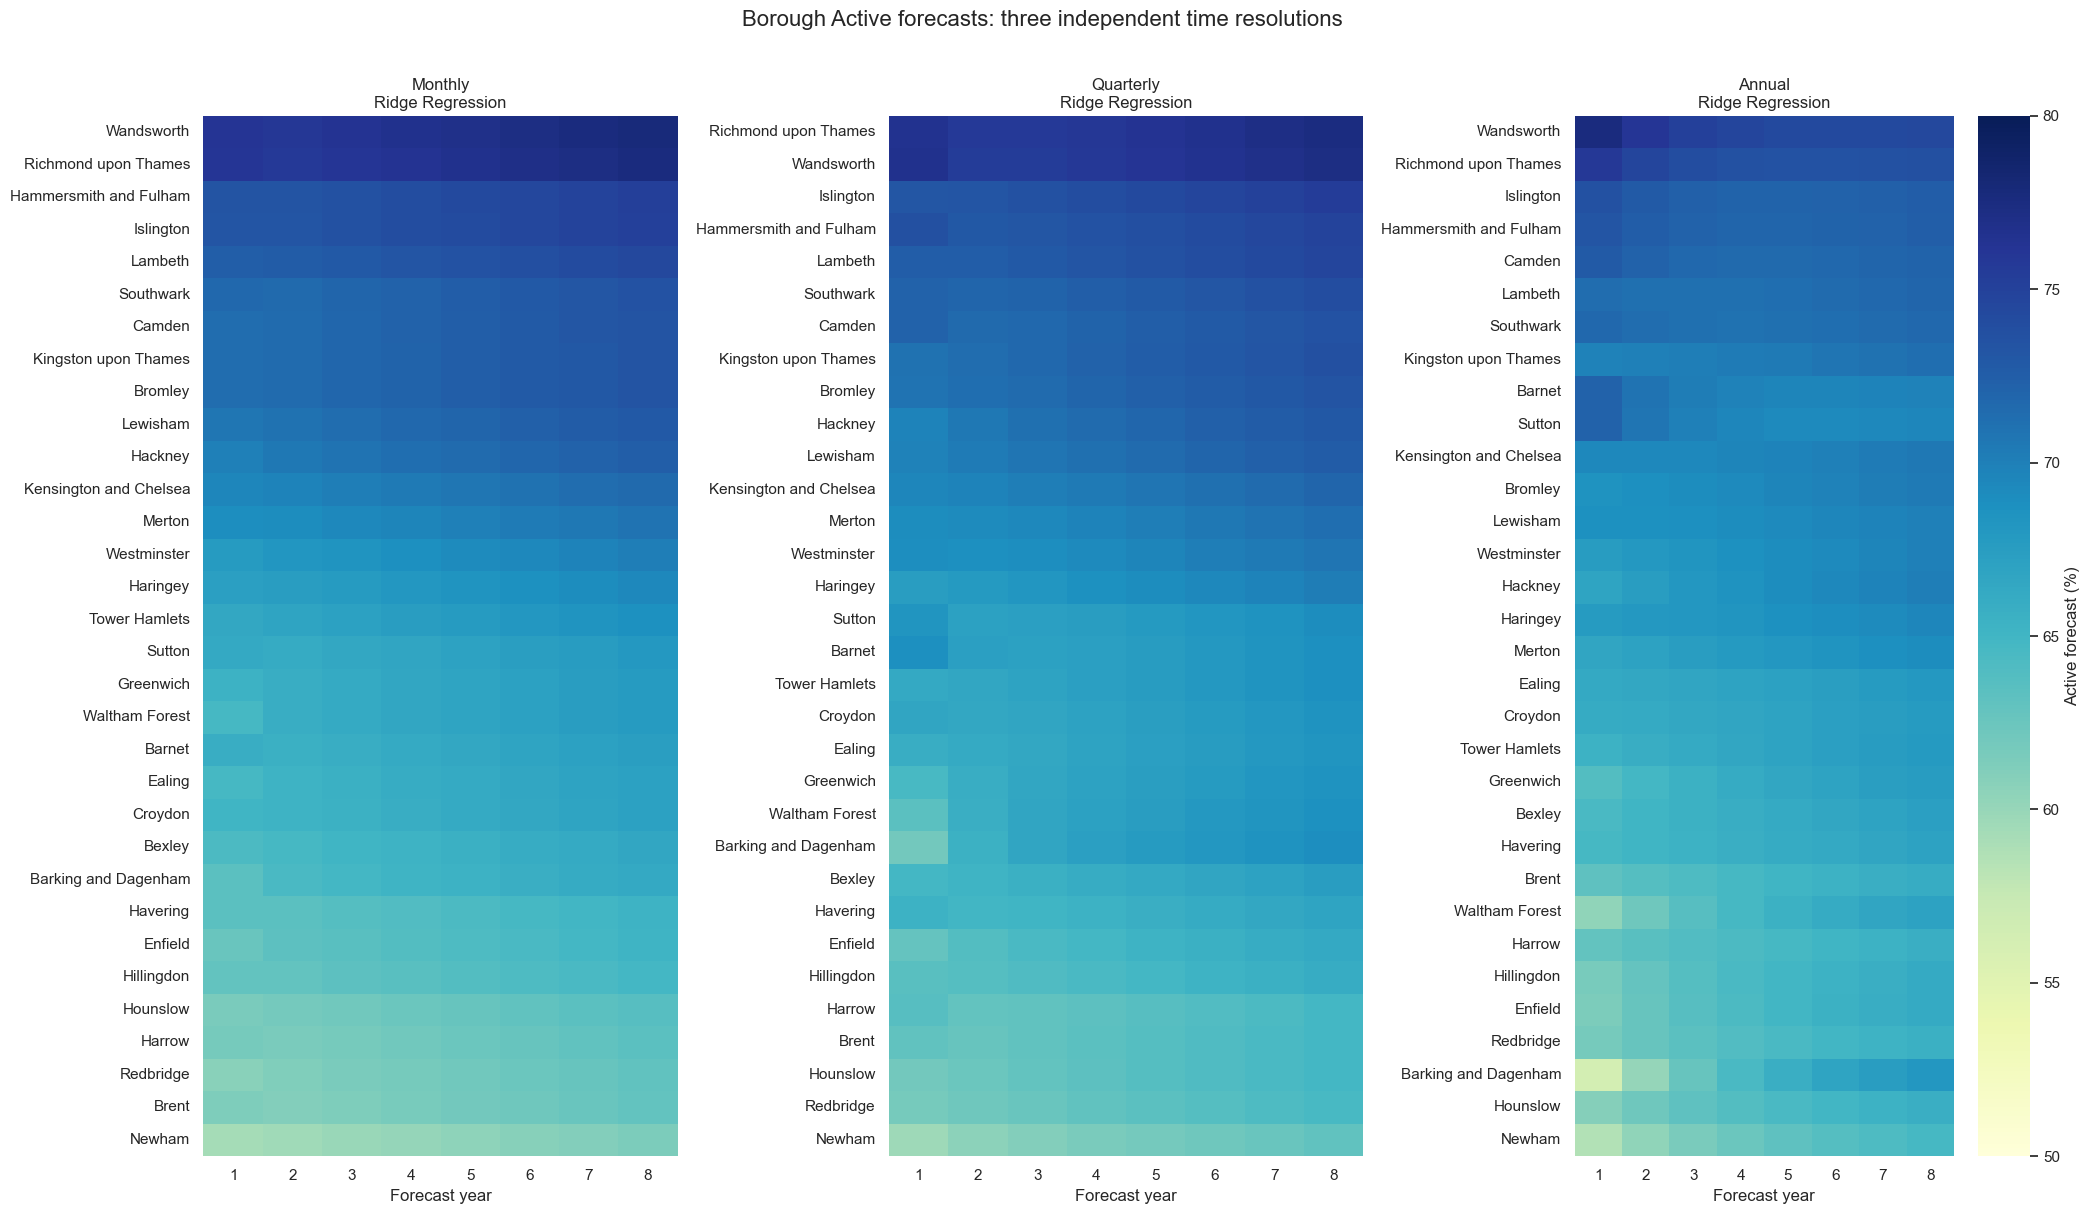

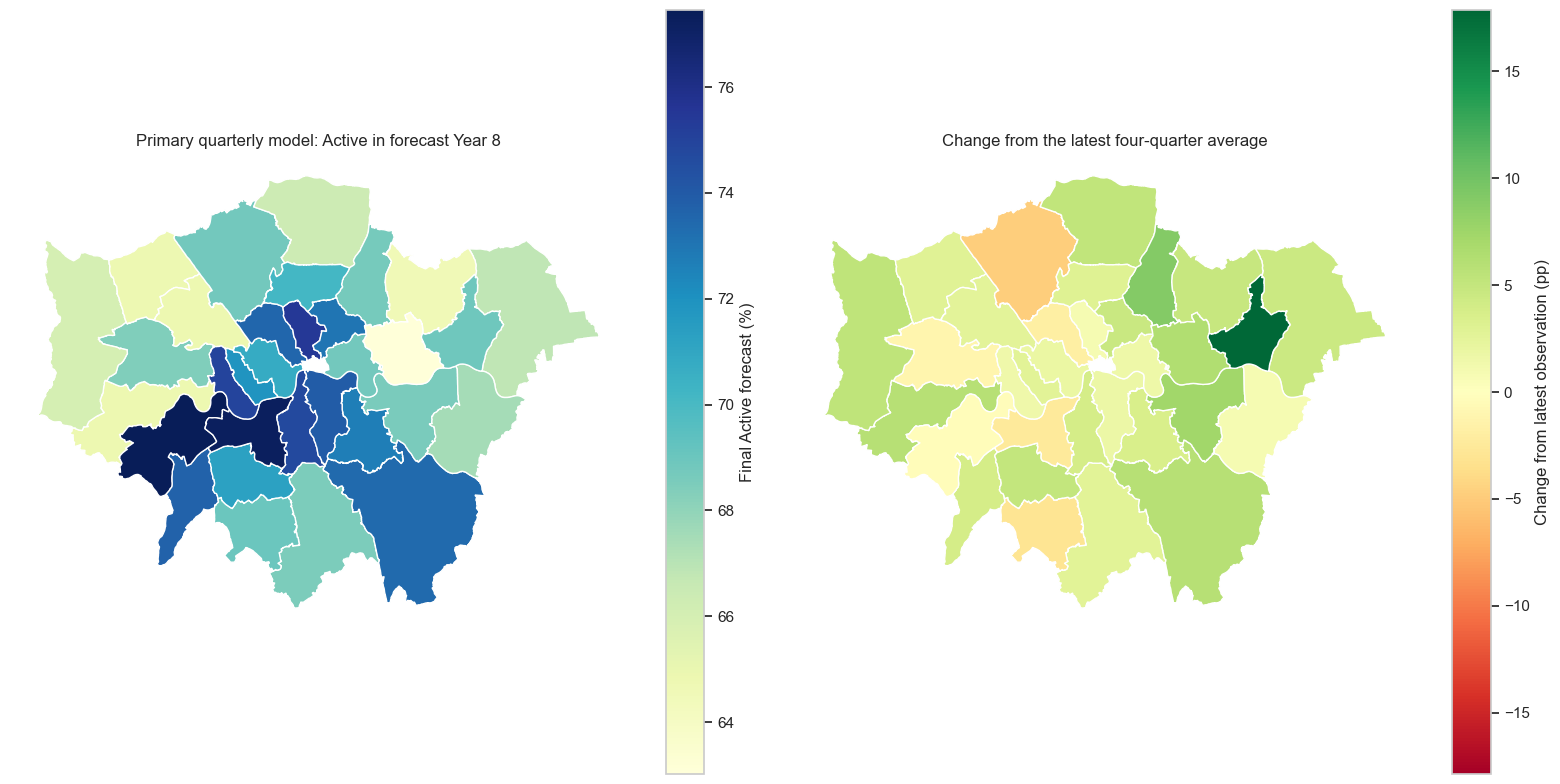

In [7]:
# Compare borough models and display annualised Active forecasts for all 32 boroughs.
plot_model_comparison('Borough')

def annualise_future(frame, frequency):
    """Convert future steps to forecast years for an interpretable borough heatmap."""
    periods = FREQUENCY_CONFIG[frequency]['periods_per_year']
    result = frame.copy()
    result['forecast_year'] = ((result['future_step'] - 1) // periods + 1).astype(int)
    return result.groupby(['geography_code', 'geography_name', 'forecast_year'], as_index=False)[
        'predicted_active_rate'
    ].mean()


# Build the figure that presents the comparison clearly.
fig, axes = plt.subplots(1, 3, figsize=(21, 12))
for axis, frequency in zip(axes, FREQUENCIES):
    future = selected_forecasts.loc[
        selected_forecasts['geographic_level'].eq('Borough')
        & selected_forecasts['frequency'].eq(frequency)
    ]
    annualised = annualise_future(future, frequency)
    matrix = annualised.pivot(
        index='geography_name', columns='forecast_year', values='predicted_active_rate'
    ) * 100
    # Calculate and store matrix for the following analysis step.
    matrix = matrix.loc[matrix.mean(axis=1).sort_values(ascending=False).index]
    sns.heatmap(matrix, cmap='YlGnBu', vmin=50, vmax=80, ax=axis,
                cbar=frequency == 'Annual', cbar_kws={'label': 'Active forecast (%)'})
    selected = selection_table.query("Geography == 'Borough' and Frequency == @frequency")['Selected model'].iloc[0]
    axis.set(title=f'{frequency}\n{selected}', xlabel='Forecast year', ylabel='')
# Create or format the figure for this comparison.
fig.suptitle('Borough Active forecasts: three independent time resolutions', fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

quarterly_final_year = annualise_future(
    selected_forecasts.loc[
        selected_forecasts['geographic_level'].eq('Borough')
        & selected_forecasts['frequency'].eq('Quarterly')
    ],
    'Quarterly',
).loc[lambda frame: frame['forecast_year'].eq(8)].copy()
# Define the time split or forecast horizon used for evaluation.
latest_quarter = panels[('Borough', 'Quarterly')]['quarter_index'].max()
latest_active = panels[('Borough', 'Quarterly')].loc[
    lambda frame: frame['quarter_index'].gt(latest_quarter - 4)
].groupby('geography_code', as_index=False)['active_rate'].mean()
quarterly_final_year = quarterly_final_year.merge(
    latest_active, on='geography_code', validate='one_to_one'
)
# Calculate and store quarterly final year['change pp'] for the following analysis step.
quarterly_final_year['change_pp'] = (
    quarterly_final_year['predicted_active_rate'] - quarterly_final_year['active_rate']
) * 100
quarterly_final_year['predicted_active_pct'] = quarterly_final_year['predicted_active_rate'] * 100
forecast_map = borough_boundaries.merge(
    quarterly_final_year, left_on='gss_code', right_on='geography_code', validate='one_to_one'
)

# Build the figure that presents the comparison clearly.
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
forecast_map.plot(column='predicted_active_pct', cmap='YlGnBu', edgecolor='white', legend=True,
                  legend_kwds={'label': 'Final Active forecast (%)'}, ax=axes[0])
axes[0].set_title('Primary quarterly model: Active in forecast Year 8')
limit = max(abs(forecast_map['change_pp'].min()), abs(forecast_map['change_pp'].max()))
forecast_map.plot(column='change_pp', cmap='RdYlGn', vmin=-limit, vmax=limit,
                  edgecolor='white', legend=True,
                  legend_kwds={'label': 'Change from latest observation (pp)'}, ax=axes[1])
# Create or format the figure for this comparison.
axes[1].set_title('Change from the latest four-quarter average')
for axis in axes:
    axis.set_axis_off()
fig.tight_layout()
plt.show()


## 6. Formal selection and Year 8 test

The model matrix records decisions made from Year 7 using activity-history features only. The external experiment above is deliberately separate and does not alter the specification. The test table reports the single untouched Year 8 evaluation after refitting each selected base model on Years 1–7.

The overall model chart summarises Year 7 performance relative to Naive. It is a selection result, not a replacement for the Year 8 test.


Frequency,Monthly,Quarterly,Annual
Geography,,,
London,Gradient Boosting,Ridge Regression,Ridge Regression
Inner/Outer,Gradient Boosting,Ridge Regression,Random Forest
Borough,Ridge Regression,Ridge Regression,Ridge Regression


,Geography,Frequency,Official external variables
0,London,Monthly,None — experiment only
1,London,Quarterly,None — experiment only
2,London,Annual,None — experiment only
3,Inner/Outer,Monthly,None — experiment only
4,Inner/Outer,Quarterly,None — experiment only
5,Inner/Outer,Annual,None — experiment only
6,Borough,Monthly,None — experiment only
7,Borough,Quarterly,None — experiment only
8,Borough,Annual,None — experiment only


,Geography,Frequency,Selected model,External design,Test TV
0,London,Monthly,Gradient Boosting,Base history only,2.43
1,London,Quarterly,Ridge Regression,Base history only,1.65
2,London,Annual,Ridge Regression,Base history only,0.62
3,Inner/Outer,Monthly,Gradient Boosting,Base history only,3.00
4,Inner/Outer,Quarterly,Ridge Regression,Base history only,2.15
5,Inner/Outer,Annual,Random Forest,Base history only,1.15
6,Borough,Monthly,Ridge Regression,Base history only,10.02
7,Borough,Quarterly,Ridge Regression,Base history only,6.66
8,Borough,Annual,Ridge Regression,Base history only,3.85


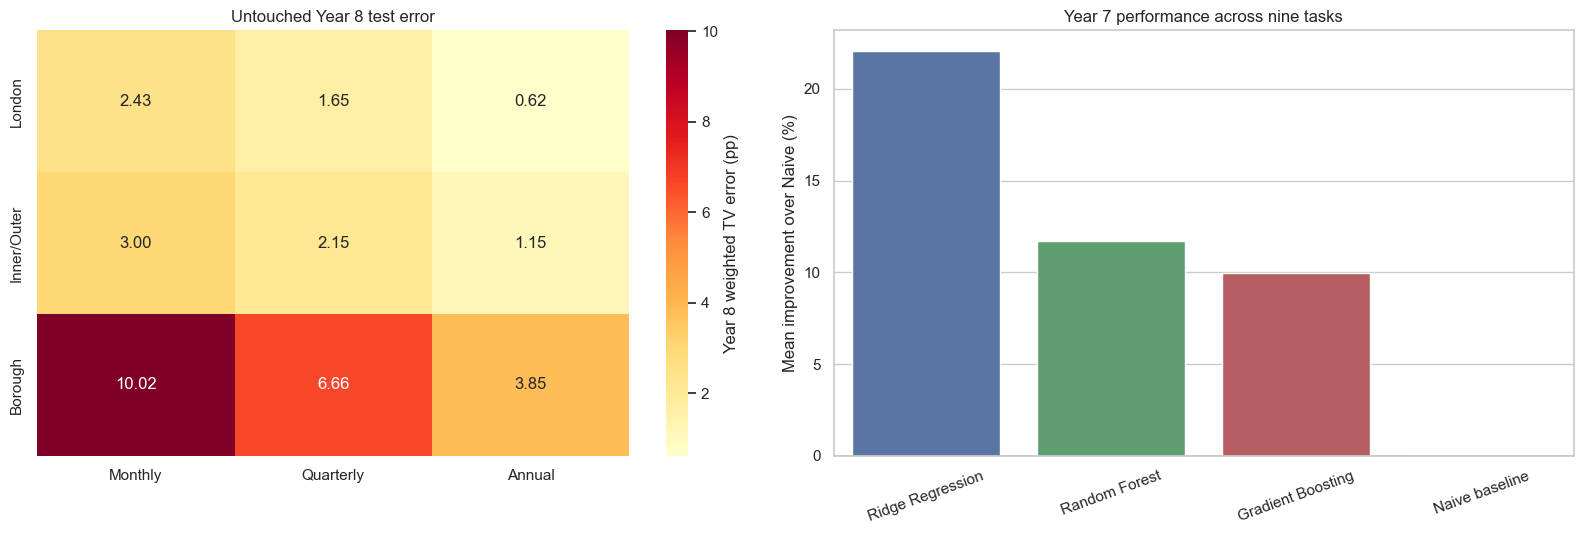

,model,mean_skill_pct,tasks_beating_naive
3,Ridge Regression,22.1,8
2,Random Forest,11.7,7
0,Gradient Boosting,9.9,7
1,Naive baseline,0.0,0


In [8]:
# Report the frozen specification, untouched test error and validation-wide comparison.
selection_matrix = selection_table.pivot(
    index='Geography', columns='Frequency', values='Selected model'
).reindex(index=LEVELS, columns=FREQUENCIES)
display(selection_matrix)
display(selection_table[['Geography', 'Frequency']].assign(
    **{'Official external variables': 'None — experiment only'}
))

# Define the time split or forecast horizon used for evaluation.
test_matrix = test_summary.pivot(
    index='Geography', columns='Frequency', values='Test TV'
).reindex(index=LEVELS, columns=FREQUENCIES) * 100
display(test_summary[['Geography', 'Frequency', 'Selected model', 'External design', 'Test TV']]
        .assign(**{'Test TV': lambda frame: frame['Test TV'] * 100}).round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
# Add this result to the current visual comparison.
sns.heatmap(test_matrix, cmap='YlOrRd', annot=True, fmt='.2f',
            cbar_kws={'label': 'Year 8 weighted TV error (pp)'}, ax=axes[0])
axes[0].set(title='Untouched Year 8 test error', xlabel='', ylabel='')

relative = model_summary.merge(
    model_summary.loc[model_summary['model'].eq('Naive baseline'),
                      ['geographic_level', 'frequency', 'mean']].rename(columns={'mean': 'naive_error'}),
    on=['geographic_level', 'frequency'], validate='many_to_one'
)
# Calculate and store relative['error relative to naive'] for the following analysis step.
relative['error_relative_to_naive'] = relative['mean'] / relative['naive_error']
overall_models = relative.groupby('model', as_index=False).agg(
    mean_relative_error=('error_relative_to_naive', 'mean'),
    tasks_beating_naive=('error_relative_to_naive', lambda values: int((values < 1).sum())),
)
overall_models['mean_skill_pct'] = (1 - overall_models['mean_relative_error']) * 100
overall_models = overall_models.sort_values('mean_relative_error')
# Add this result to the current visual comparison.
sns.barplot(data=overall_models, x='model', y='mean_skill_pct',
            palette=MODEL_COLORS, hue='model', legend=False, ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set(title='Year 7 performance across nine tasks', xlabel='',
            ylabel='Mean improvement over Naive (%)')
axes[1].tick_params(axis='x', rotation=20)
fig.tight_layout()
# Display the finished visual or summary for interpretation.
plt.show()
display(overall_models[['model', 'mean_skill_pct', 'tasks_beating_naive']].round(1))


## 7. What information drives the quarterly forecasts?

All three quarterly tasks selected Ridge Regression, so interpretation can stay focused on the primary forecasting frequency. The following checks use Years 1–6 to predict Year 7; the Year 8 test is not reused for explanation. Because Year 7 was also used for model selection, this is a conditional sensitivity diagnostic rather than a second independent validation exercise.

The first figure removes one predictor group at a time, refits the model and reports the change in weighted TV error. A positive value means that error rises when the group is removed, so that group helped the Year 7 forecast. A negative value means the reduced model performed slightly better. All variants use the same warm-up sample to make the comparison fair.

The second figure shows the largest standardized Ridge coefficients for the Active equation. Their signs describe predictive associations, not causal effects. Because lagged activity variables are correlated and predictions are subsequently rescaled to sum to 100%, individual coefficients should be read together with the more robust group-ablation result. External variables are not shown because none was adopted in the official specification.


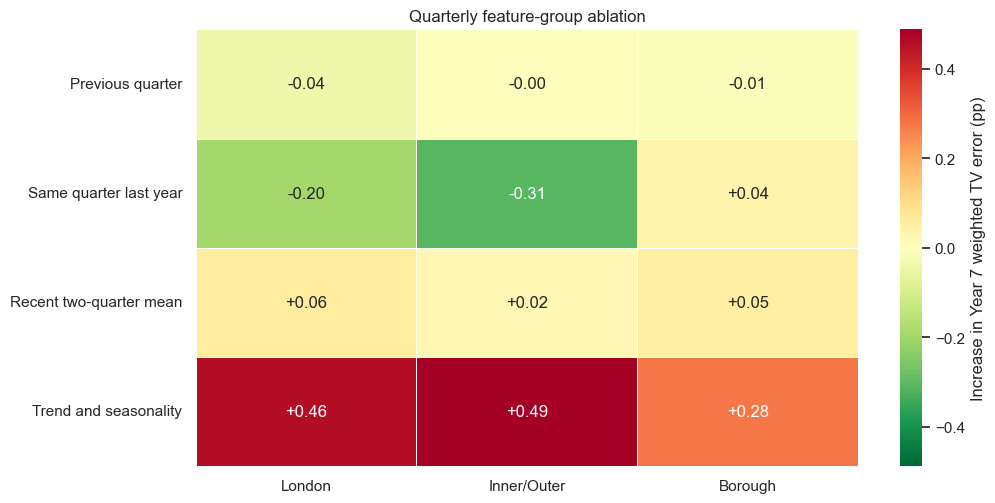

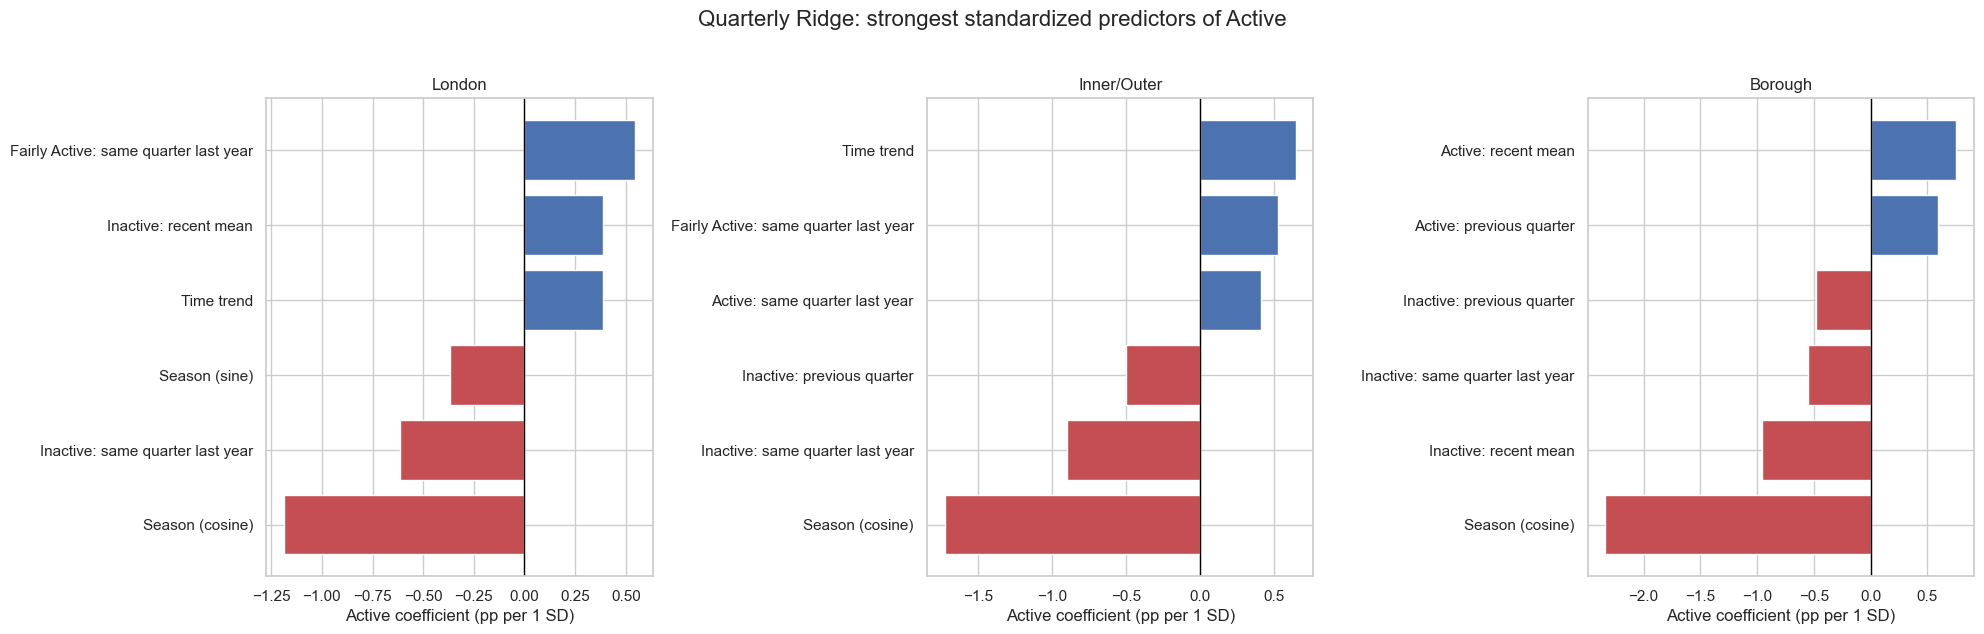

In [9]:
# Explain the three primary quarterly Ridge forecasts using Year 7 only.
quarterly_config = FREQUENCY_CONFIG['Quarterly']
quarterly_feature_groups = {
    'Previous quarter': [f'{target}_lag1' for target in TARGETS],
    'Same quarter last year': [f'{target}_seasonal_lag' for target in TARGETS],
    'Recent two-quarter mean': [f'{target}_recent_mean' for target in TARGETS],
    'Trend and seasonality': ['trend_years', 'season_sin', 'season_cos'],
}

# Refit the full and reduced specifications on the identical Years 1-6 sample.
ablation_rows = []
for level in LEVELS:
    choice = task_choices[(level, 'Quarterly')]
    training = panels[(level, 'Quarterly')].loc[lambda frame: frame['year'].le(6)].copy()
    validation = panels[(level, 'Quarterly')].loc[lambda frame: frame['year'].eq(7)].copy()
    full_forecast = recursive_forecast(
        training, quarterly_config, choice['model'], choice['external_features'], horizon=4
    )
    full_matched, _ = score_forecast(full_forecast, validation, quarterly_config)
    full_error = np.average(full_matched['row_tv'], weights=full_matched['effective_n'])

    for group_name, excluded in quarterly_feature_groups.items():
        reduced_forecast = recursive_forecast(
            training, quarterly_config, choice['model'], choice['external_features'],
            horizon=4, excluded_features=excluded,
        )
        reduced_matched, _ = score_forecast(reduced_forecast, validation, quarterly_config)
        reduced_error = np.average(
            reduced_matched['row_tv'], weights=reduced_matched['effective_n']
        )
        ablation_rows.append({
            'Geography': level, 'Feature group': group_name,
            'Error increase (pp)': (reduced_error - full_error) * 100,
        })

ablation_results = pd.DataFrame(ablation_rows)
ablation_matrix = ablation_results.pivot(
    index='Feature group', columns='Geography', values='Error increase (pp)'
).reindex(index=quarterly_feature_groups, columns=LEVELS)

# A compact diverging heatmap makes helpful and unhelpful groups immediately visible.
limit = max(.05, np.abs(ablation_matrix.to_numpy()).max())
fig, axis = plt.subplots(figsize=(10.5, 5.2))
sns.heatmap(
    ablation_matrix, cmap='RdYlGn_r', center=0, vmin=-limit, vmax=limit,
    annot=True, fmt='+.2f', linewidths=.6,
    cbar_kws={'label': 'Increase in Year 7 weighted TV error (pp)'}, ax=axis,
)
axis.set(title='Quarterly feature-group ablation', xlabel='', ylabel='')
fig.tight_layout()
plt.show()

# Fit the same Ridge specifications and extract standardized numeric coefficients.
coefficient_rows = []
for level in LEVELS:
    training = panels[(level, 'Quarterly')].loc[lambda frame: frame['year'].le(6)].copy()
    supervised, numeric_features = make_supervised(training, quarterly_config, [])
    weights = np.clip(
        supervised['effective_n'], supervised['effective_n'].quantile(.05),
        supervised['effective_n'].quantile(.95),
    )
    weights = weights / weights.mean()
    ridge_pipeline = build_model('Ridge Regression', numeric_features, len(supervised))
    ridge_pipeline.fit(
        supervised[numeric_features + ['geography_code']], supervised[TARGETS],
        model__sample_weight=weights,
    )
    active_coefficients = ridge_pipeline.named_steps['model'].coef_[TARGETS.index('active_rate')]
    for feature, coefficient in zip(numeric_features, active_coefficients[:len(numeric_features)]):
        coefficient_rows.append({
            'Geography': level, 'Feature': feature,
            'Coefficient (pp)': coefficient * 100,
        })

coefficient_results = pd.DataFrame(coefficient_rows)
feature_labels = {
    **{f'{target}_lag1': f'{TARGET_LABELS[target]}: previous quarter' for target in TARGETS},
    **{f'{target}_seasonal_lag': f'{TARGET_LABELS[target]}: same quarter last year' for target in TARGETS},
    **{f'{target}_recent_mean': f'{TARGET_LABELS[target]}: recent mean' for target in TARGETS},
    'trend_years': 'Time trend', 'season_sin': 'Season (sine)', 'season_cos': 'Season (cosine)',
}
coefficient_results['Label'] = coefficient_results['Feature'].map(feature_labels)
coefficient_results['Absolute coefficient'] = coefficient_results['Coefficient (pp)'].abs()
top_coefficients = coefficient_results.sort_values(
    ['Geography', 'Absolute coefficient'], ascending=[True, False]
).groupby('Geography', as_index=False).head(6)

# Show direction and magnitude for the six strongest Active predictors in each task.
fig, axes = plt.subplots(1, 3, figsize=(20, 6.2))
for axis, level in zip(axes, LEVELS):
    local = top_coefficients.loc[
        top_coefficients['Geography'].eq(level)
    ].sort_values('Coefficient (pp)')
    colors = np.where(local['Coefficient (pp)'].ge(0), '#4C72B0', '#C44E52')
    axis.barh(local['Label'], local['Coefficient (pp)'], color=colors)
    axis.axvline(0, color='black', linewidth=1)
    axis.set(title=level, xlabel='Active coefficient (pp per 1 SD)', ylabel='')
fig.suptitle('Quarterly Ridge: strongest standardized predictors of Active', fontsize=16, y=1.02)
fig.tight_layout()
plt.show()


### What the diagnostics show

Trend and seasonality is the only group that consistently improves the held-out Year 7 forecast: removing it raises weighted TV error by 0.46 points for London, 0.49 for Inner/Outer and 0.28 for Borough. The recent two-quarter mean adds a smaller but consistent benefit of 0.02–0.06 points.

The other lags are less transferable. Removing the previous-quarter group changes error by almost zero, while removing the same-quarter-last-year group improves London and Inner/Outer by 0.20 and 0.31 points but worsens Borough by 0.04 points. The annual seasonal lag therefore carries some local information at borough level but is not uniformly useful at broader geographies.

The coefficient chart agrees that seasonal timing is prominent and shows the expected local persistence: higher recent Active predicts higher Active, while recent Inactive predicts lower Active, especially for Borough. Some large seasonal-lag coefficients coexist with weak ablation performance because correlated Ridge predictors share information. For that reason, coefficient magnitude alone is not treated as evidence that a feature improves forecasting accuracy.


## 8. How much do the four models disagree about the future?

Historical error alone does not reveal whether models produce similar long-term paths. For each task and forecast year, the heatmap measures the gap between the highest and lowest Active forecast among Naive, Ridge, Random Forest and Gradient Boosting. Borough values are summarised by their median spread so one extreme area does not dominate the comparison.

A widening band means the future result depends increasingly on model assumptions. It is a warning about structural uncertainty even when the selected model has the lowest historical error.


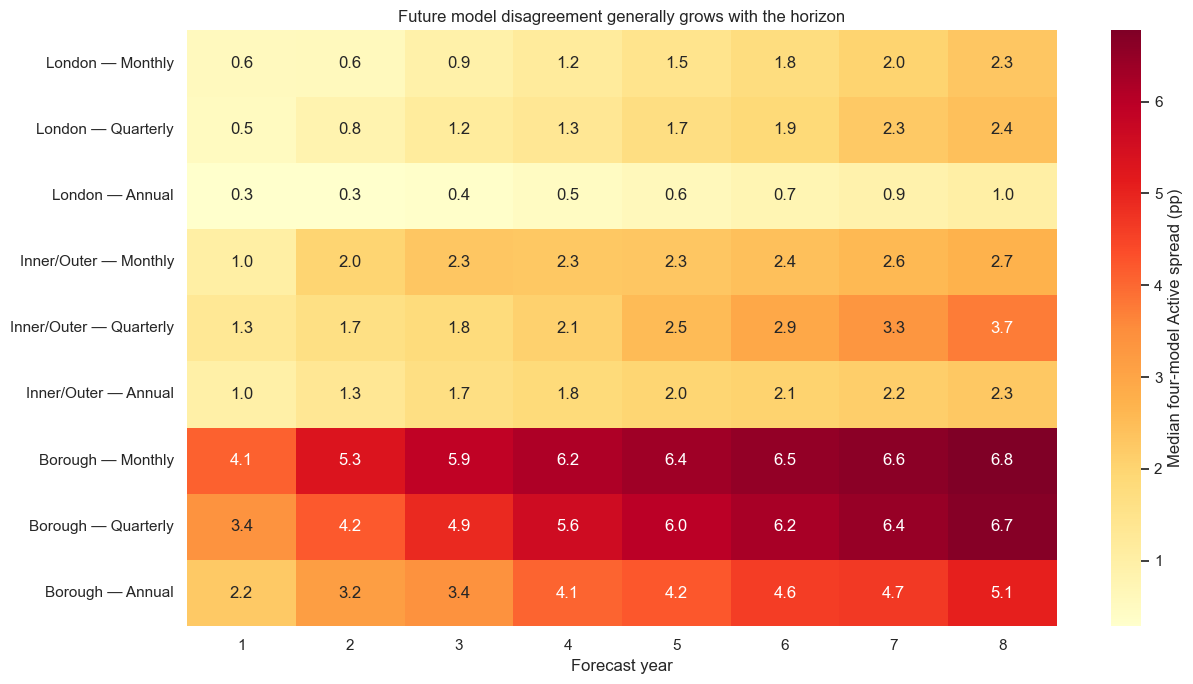

,Geography,Frequency,Median spread (pp),90th percentile spread (pp)
7,London,Monthly,2.3,2.3
15,London,Quarterly,2.4,2.4
23,London,Annual,1.0,1.0
31,Inner/Outer,Monthly,2.7,2.9
39,Inner/Outer,Quarterly,3.7,4.5
47,Inner/Outer,Annual,2.3,3.6
55,Borough,Monthly,6.8,9.8
63,Borough,Quarterly,6.7,8.7
71,Borough,Annual,5.1,7.9


In [10]:
# Measure future Active disagreement across all four fitted model families.
model_spread_rows = []
for level in LEVELS:
    for frequency in FREQUENCIES:
        local = future_forecasts.loc[
            future_forecasts['geographic_level'].eq(level)
            & future_forecasts['frequency'].eq(frequency)
        ].copy()
        periods = FREQUENCY_CONFIG[frequency]['periods_per_year']
        local['forecast_year'] = ((local['future_step'] - 1) // periods + 1).astype(int)
        annual_model_values = local.groupby([
            'geography_code', 'forecast_year', 'model'
        ], as_index=False)['predicted_active_rate'].mean()
        # Calculate and store by area for the following analysis step.
        by_area = annual_model_values.groupby([
            'geography_code', 'forecast_year'
        ])['predicted_active_rate'].agg(lambda values: values.max() - values.min()).reset_index()
        yearly = by_area.groupby('forecast_year')['predicted_active_rate'].agg(
            median_spread='median', p90_spread=lambda values: values.quantile(.90)
        ).reset_index()
        yearly['Geography'], yearly['Frequency'] = level, frequency
        # Fit the specified model to the prepared analysis sample.
        model_spread_rows.append(yearly)

# Fit the model using the specification defined for this comparison.
model_disagreement = pd.concat(model_spread_rows, ignore_index=True)
model_disagreement['Task'] = (
    model_disagreement['Geography'] + ' — ' + model_disagreement['Frequency']
)
spread_matrix = model_disagreement.pivot(
    index='Task', columns='forecast_year', values='median_spread'
).reindex([f'{level} — {frequency}' for level in LEVELS for frequency in FREQUENCIES]) * 100

# Build the figure that presents the comparison clearly.
fig, axis = plt.subplots(figsize=(13, 7))
sns.heatmap(spread_matrix, cmap='YlOrRd', annot=True, fmt='.1f',
            cbar_kws={'label': 'Median four-model Active spread (pp)'}, ax=axis)
axis.set(title='Future model disagreement generally grows with the horizon',
         xlabel='Forecast year', ylabel='')
fig.tight_layout()
plt.show()

# Calculate and store final year disagreement for the following analysis step.
final_year_disagreement = model_disagreement.loc[
    model_disagreement['forecast_year'].eq(8),
    ['Geography', 'Frequency', 'median_spread', 'p90_spread'],
].copy()
final_year_disagreement[['median_spread', 'p90_spread']] *= 100
display(final_year_disagreement.rename(columns={
    'median_spread': 'Median spread (pp)', 'p90_spread': '90th percentile spread (pp)'
}).round(1))


## 9. Fixed-origin multi-step reliability

This is not an expanding backtest. Each selected specification is trained once on Years 1–6 and then forecasts Years 7–8 continuously without updating from Year 7 outcomes. It therefore tests whether a model chosen for the first forecast year remains credible in the second.

Monthly paths contain 24 steps, quarterly paths 8 and annual paths 2. The Year 7 portion was used for selection, so the second-year error is the more demanding part of this diagnostic. With only two future historical years, the exercise still cannot prove accuracy eight years ahead.


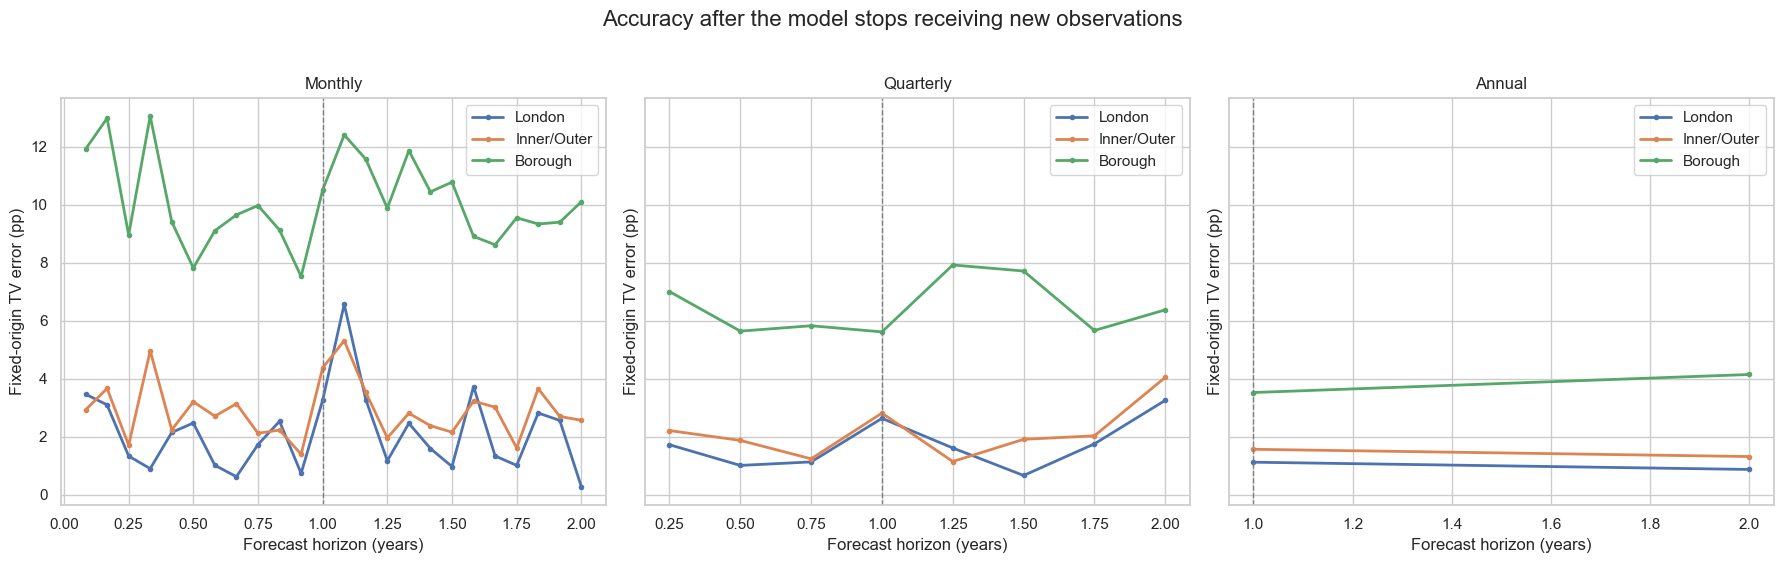

forecast_year,Geography,Frequency,Year 7 error,Year 8 error,Second-year change (%)
0,Borough,Annual,3.52,4.14,17.67
1,Borough,Monthly,9.85,10.18,3.30
2,Borough,Quarterly,6.01,6.90,14.84
3,Inner/Outer,Annual,1.56,1.31,-16.01
4,Inner/Outer,Monthly,2.78,2.83,1.64
5,Inner/Outer,Quarterly,2.02,2.32,15.01
6,London,Annual,1.12,0.87,-22.38
7,London,Monthly,1.84,2.18,18.49
8,London,Quarterly,1.62,1.84,13.62


In [11]:
# Forecast Years 7–8 once from the fixed end-of-Year-6 origin.
multistep_parts = []
for level in LEVELS:
    for frequency in FREQUENCIES:
        panel, config = panels[(level, frequency)], FREQUENCY_CONFIG[frequency]
        choice = task_choices[(level, frequency)]
        training = panel.loc[panel['year'].le(6)].copy()
        actual = panel.loc[panel['year'].isin([7, 8])].copy()
        horizon = 2 * config['periods_per_year']
        predicted = recursive_forecast(
            training, config, choice['model'], choice['external_features'], horizon
        )
        # Calculate and store matched,  for the following analysis step.
        matched, _ = score_forecast(predicted, actual, config)
        matched['Geography'], matched['Frequency'] = level, frequency
        multistep_parts.append(matched)

# Calculate and store multistep predictions for the following analysis step.
multistep_predictions = pd.concat(multistep_parts, ignore_index=True)
multistep_scores = multistep_predictions.groupby([
    'Geography', 'Frequency', 'future_step'
]).apply(
    lambda frame: np.average(frame['row_tv'], weights=frame['effective_n']),
    include_groups=False,
).rename('weighted_tv').reset_index()
# Calculate and store multistep scores['horizon years'] for the following analysis step.
multistep_scores['horizon_years'] = multistep_scores.apply(
    lambda row: row['future_step'] / FREQUENCY_CONFIG[row['Frequency']]['periods_per_year'],
    axis=1,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
for axis, frequency in zip(axes, FREQUENCIES):
    local = multistep_scores.loc[multistep_scores['Frequency'].eq(frequency)]
    for level, color in zip(LEVELS, ['#4C72B0', '#DD8452', '#55A868']):
        line = local.loc[local['Geography'].eq(level)]
        axis.plot(line['horizon_years'], line['weighted_tv'] * 100,
                  marker='o', markersize=3, linewidth=2, color=color, label=level)
    axis.axvline(1, color='grey', linestyle='--', linewidth=1)
    axis.set(title=frequency, xlabel='Forecast horizon (years)',
             ylabel='Fixed-origin TV error (pp)')
    # Apply the next transformation to the prepared analysis object.
    axis.legend()
# Create or format the figure for this comparison.
fig.suptitle('Accuracy after the model stops receiving new observations', fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

yearly_multistep = multistep_predictions.assign(
    forecast_year=lambda frame: frame.apply(
        lambda row: int(np.ceil(row['future_step'] /
                                FREQUENCY_CONFIG[row['Frequency']]['periods_per_year'])), axis=1
    )
).groupby(['Geography', 'Frequency', 'forecast_year']).apply(
    lambda frame: np.average(frame['row_tv'], weights=frame['effective_n']),
    include_groups=False,
).rename('weighted_tv').reset_index()
# Calculate and store degradation for the following analysis step.
degradation = yearly_multistep.pivot(
    index=['Geography', 'Frequency'], columns='forecast_year', values='weighted_tv'
).reset_index().rename(columns={1: 'Year 7 error', 2: 'Year 8 error'})
degradation['Second-year change (%)'] = (
    degradation['Year 8 error'] / degradation['Year 7 error'] - 1
) * 100
display(degradation.assign(
    **{'Year 7 error': degradation['Year 7 error'] * 100,
       'Year 8 error': degradation['Year 8 error'] * 100}
).round(2))


## 10. Primary forecast frequency and change summary

The three frequencies are not given equal reporting status. The **quarterly forecast is the primary result** because it offers the best evidentiary balance: 32 historical periods, explicit seasonality, larger effective samples than borough-month estimates and fewer recursive steps than the 96-month path.

This is not a claim that quarterly wins every diagnostic. In the fixed-origin test, quarterly second-year error rises for all three geographic levels, although its absolute error remains below monthly error. Annual errors are lower because annual aggregation removes much survey noise, but London and Inner/Outer annual validation and testing each contain only one point. Annual forecasts therefore remain a long-term sensitivity check rather than the sole main result. Monthly forecasts are operational, most useful over approximately the next 12 months.

The change summary compares the average of the last four observed quarters with the average of the four quarters in forecast Year 8. This keeps the target definition consistent while removing quarter-specific seasonality. London, Inner and Outer London are reported directly; the borough distribution and largest projected changes are shown separately.


,Geography,Area,Quarterly model,Inactive change (pp),Fairly Active change (pp),Active change (pp)
32,Inner/Outer,Inner London,Ridge Regression,1.9,-4.1,2.2
33,Inner/Outer,Outer London,Ridge Regression,0.3,-4.6,4.3
34,London,London excluding City of London,Ridge Regression,1.3,-3.4,2.1


,Boroughs,Median Active change (pp),Minimum Active change (pp),Maximum Active change (pp)
0,32,2.9,-4.8,17.9


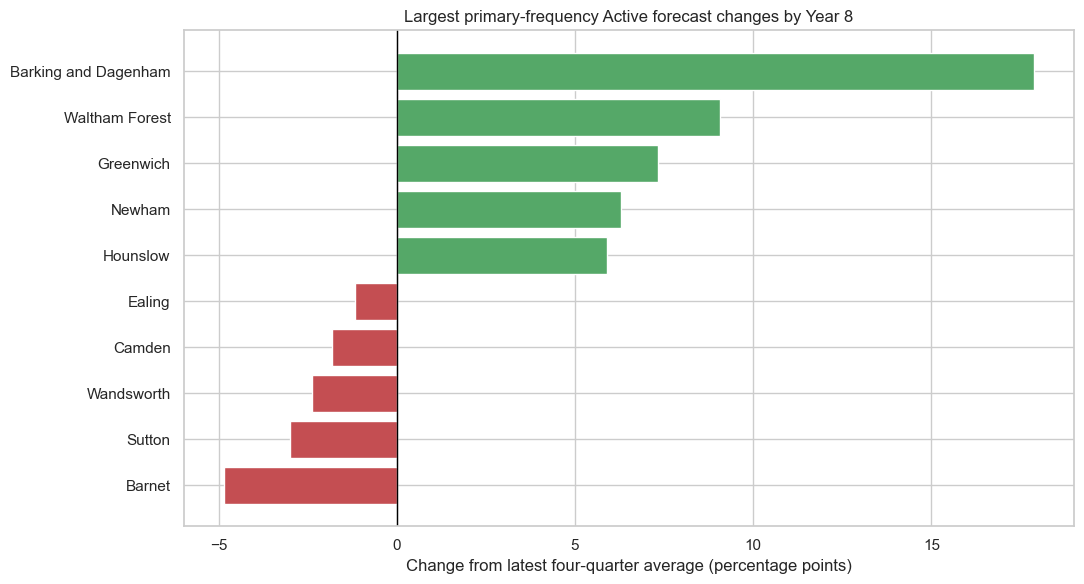

In [12]:
# Summarise forecast change using the primary quarterly frequency.
primary_quarterly = selected_forecasts.loc[
    selected_forecasts['frequency'].eq('Quarterly')
].copy()
primary_quarterly['forecast_year'] = (
    (primary_quarterly['future_step'] - 1) // 4 + 1
).astype(int)
primary_final = primary_quarterly.loc[
    primary_quarterly['forecast_year'].eq(8)
].groupby([
    'geographic_level', 'geography_code', 'geography_name', 'model'
], as_index=False)[[f'predicted_{target}' for target in TARGETS]].mean()

# Define the time split or forecast horizon used for evaluation.
latest_parts = []
for level in LEVELS:
    panel = panels[(level, 'Quarterly')]
    last_quarter = panel['quarter_index'].max()
    latest = panel.loc[panel['quarter_index'].gt(last_quarter - 4)].groupby([
        'geography_code', 'geography_name'
    ], as_index=False)[TARGETS].mean()
    latest_parts.append(latest.assign(geographic_level=level))
# Define the time split or forecast horizon used for evaluation.
latest_quarterly_year = pd.concat(latest_parts, ignore_index=True)

change_summary = primary_final.merge(
    latest_quarterly_year[['geographic_level', 'geography_code', *TARGETS]],
    on=['geographic_level', 'geography_code'], validate='one_to_one',
)
for target in TARGETS:
    change_summary[f'{target}_change_pp'] = (
        change_summary[f'predicted_{target}'] - change_summary[target]
    ) * 100

# Calculate and store aggregate change for the following analysis step.
aggregate_change = change_summary.loc[
    change_summary['geographic_level'].isin(['London', 'Inner/Outer'])
][[
    'geographic_level', 'geography_name', 'model',
    'inactive_rate_change_pp', 'fairly_active_rate_change_pp', 'active_rate_change_pp',
]].rename(columns={
    'geographic_level': 'Geography', 'geography_name': 'Area', 'model': 'Quarterly model',
    'inactive_rate_change_pp': 'Inactive change (pp)',
    'fairly_active_rate_change_pp': 'Fairly Active change (pp)',
    'active_rate_change_pp': 'Active change (pp)',
})
# Display the finished visual or summary for interpretation.
display(aggregate_change.round(1))

borough_change = change_summary.loc[
    change_summary['geographic_level'].eq('Borough')
].sort_values('active_rate_change_pp')
borough_distribution = pd.DataFrame([{
    'Boroughs': borough_change['geography_code'].count(),
    'Median Active change (pp)': borough_change['active_rate_change_pp'].median(),
    'Minimum Active change (pp)': borough_change['active_rate_change_pp'].min(),
    'Maximum Active change (pp)': borough_change['active_rate_change_pp'].max(),
}])
# Display the finished visual or summary for interpretation.
display(borough_distribution.round(1))

extremes = pd.concat([borough_change.head(5), borough_change.tail(5)]).sort_values(
    'active_rate_change_pp'
)
fig, axis = plt.subplots(figsize=(11, 6))
colors = np.where(extremes['active_rate_change_pp'].ge(0), '#55A868', '#C44E52')
# Calculate and store axis.barh(extremes['geography name'], extremes['active rate... for the following analysis step.
axis.barh(extremes['geography_name'], extremes['active_rate_change_pp'], color=colors)
axis.axvline(0, color='black', linewidth=1)
axis.set(title='Largest primary-frequency Active forecast changes by Year 8',
         xlabel='Change from latest four-quarter average (percentage points)', ylabel='')
fig.tight_layout()
plt.show()


# Final findings

## Fixed 6/1/1 design

Years 1–6 train every candidate, Year 7 selects the model family, and Year 8 is touched once after refitting on Years 1–7. External variables remain a separate experiment and do not alter the official test or future forecasts.

## Final external-variable definitions

The final experiment uses one readily interpretable variable from each dimension:

- age: population aged 65+;
- population: annual adult-population growth;
- income: median weekly earnings.

All three enter with a one-year lag and are tested separately. There are no interaction or combination models. The heatmap reports negative as well as positive results: interpretability alone is not treated as evidence of predictive value.

Weekly earnings remains the only broadly useful candidate: mean Year 7 improvement is 3.8%, seven of nine tasks improve and four reach 2%. The 65+ share has a mean improvement of −2.1% and no task reaches 2%. Population growth has a mean improvement of −4.8%; four tasks improve and three reach 2%, but losses in other tasks are large. Age and population growth are therefore retained for interpretation and transparent testing, not because they are general-purpose accuracy improvements.

## How to interpret the experiment

The Year 7 comparison asks whether each variable improves the already-selected base family. A variable that helps one geographic level or frequency is not assumed to help the others. Annual improvements remain weak temporal evidence because the validation block contains only one annual period.

None of the three variables is promoted. Year 8 test errors, future model disagreement, uncertainty bands and eight-year forecasts all continue to use activity history, seasonality and trend only.

## Quarterly forecast explanation

Year 7 feature-group ablation identifies trend and seasonality as the most dependable source of quarterly forecast skill across all three geographic levels. Recent two-quarter history adds a small consistent benefit. Previous-quarter values add little once the other history features are present, and the same-quarter-last-year lag helps only the Borough task. Standardized Ridge coefficients are reported as predictive associations for the Active equation, not as causal effects.

## Official forecasting result

Quarterly remains the primary eight-year reporting frequency, annual is the long-term sensitivity result and monthly is the short-term operational view. The fixed-origin multi-step analysis continues to show what happens when a model trained through Year 6 receives no new observations for Years 7–8.


# Report figures

Two compact displayed figures are sufficient for the forecasting section and can be downloaded directly from the notebook. The first is the substantive result: it combines the primary quarterly forecasts at London, Inner/Outer and Borough levels. Quarterly paths are averaged within forecast year only for report presentation; the fitted quarterly predictions themselves are unchanged. The second provides the evidence behind those forecasts by combining the four-model Year 7 comparison with fixed-origin quarterly horizon degradation.

Asterisks in the model heatmap identify the model selected by the predefined 2% simple-model rule. Positive skill means lower Year 7 error than the Naive baseline.


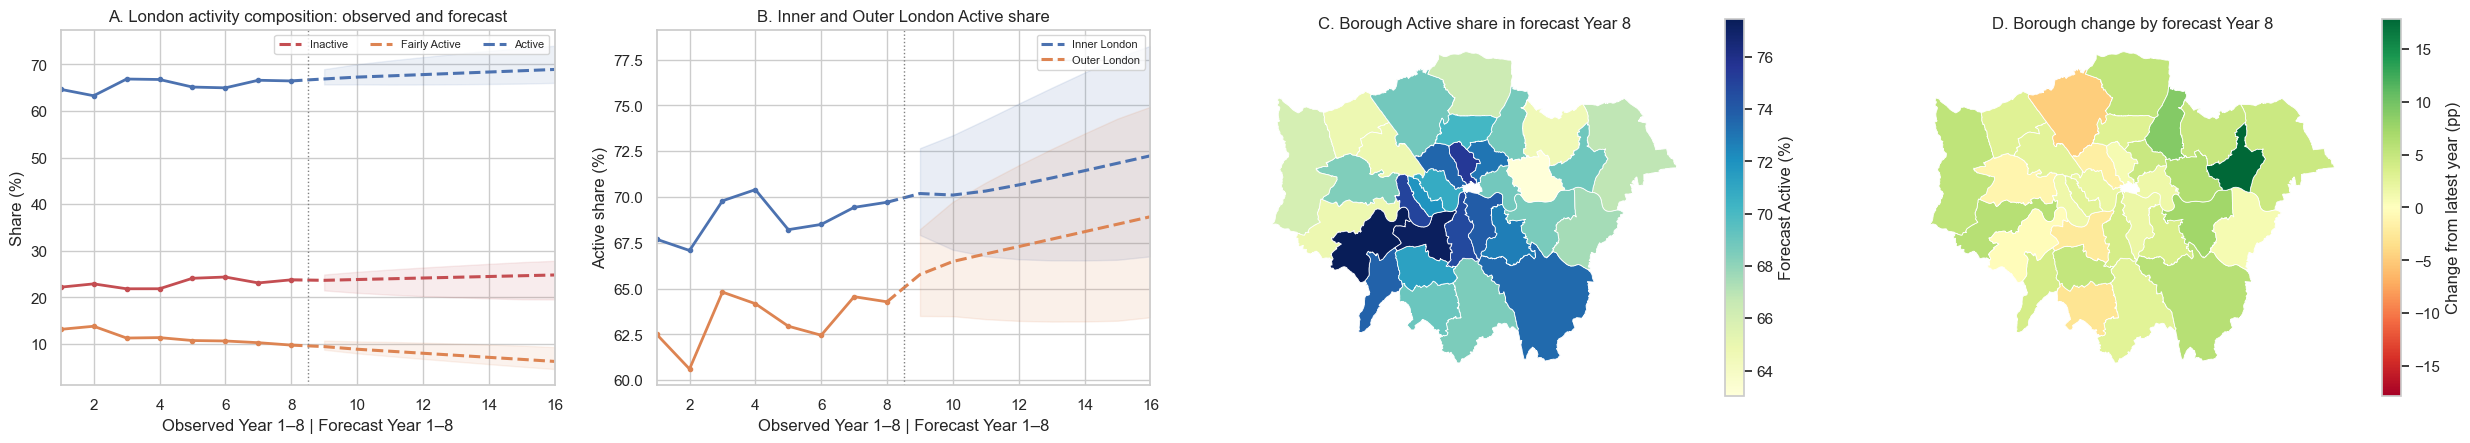

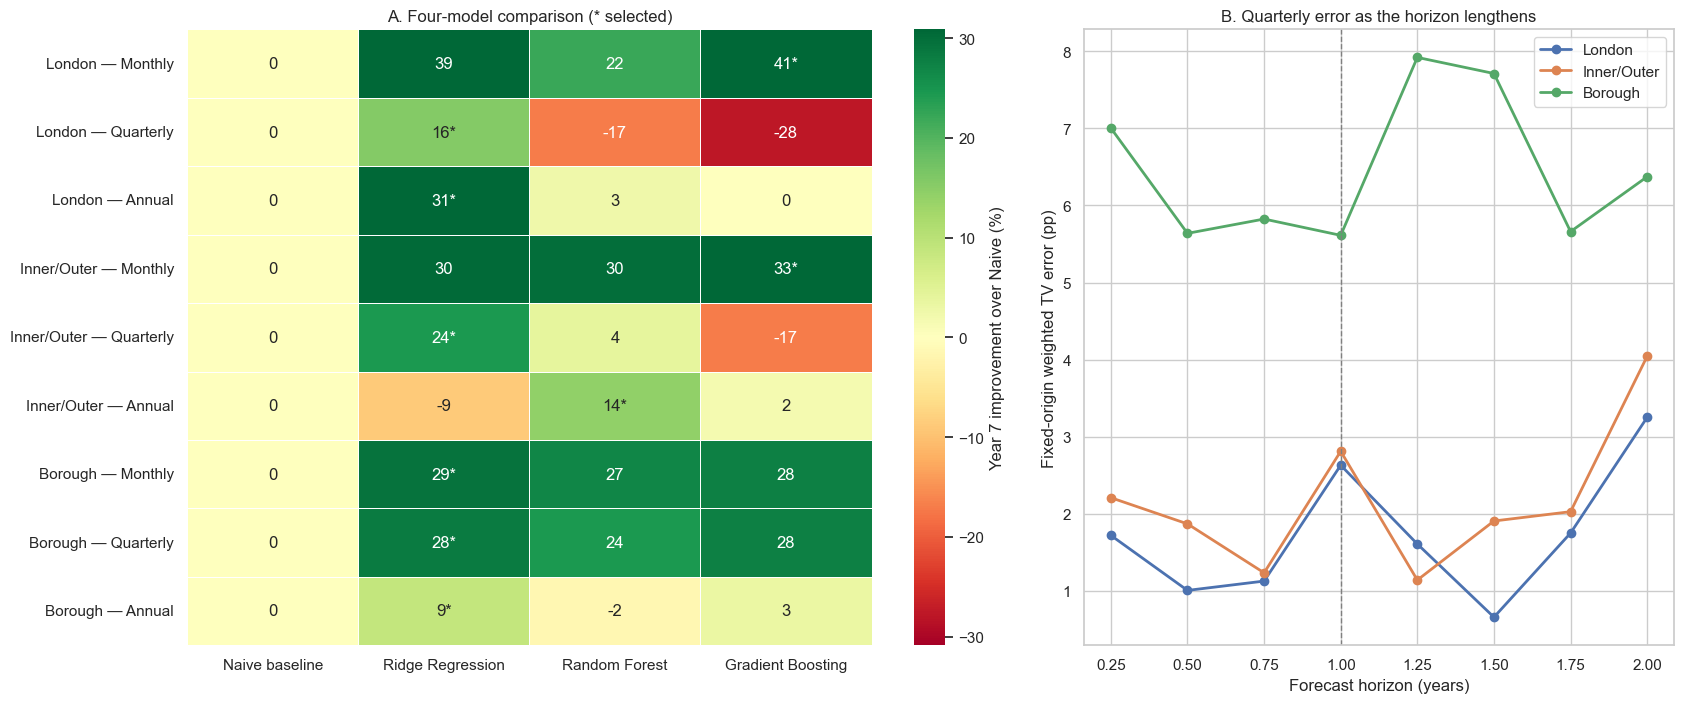

In [13]:
# Annualise the primary quarterly display without changing the fitted forecasts.
report_quarterly = selected_forecasts.loc[
    selected_forecasts['frequency'].eq('Quarterly')
].copy()
report_quarterly['forecast_year'] = ((report_quarterly['future_step'] - 1) // 4 + 1).astype(int)
forecast_columns = [
    column for target in TARGETS
    for column in (f'predicted_{target}', f'lower_{target}', f'upper_{target}')
]
report_annualised = report_quarterly.groupby([
    'geographic_level', 'geography_code', 'geography_name', 'forecast_year'
], as_index=False)[forecast_columns].mean()

# Figure 1 combines future paths and final-year spatial differences.
target_colors = {'inactive_rate': '#C44E52', 'fairly_active_rate': '#DD8452', 'active_rate': '#4C72B0'}
london_history = panels[('London', 'Annual')].sort_values('year')
london_future = report_annualised.loc[
    report_annualised['geographic_level'].eq('London')
].sort_values('forecast_year')
area_history = panels[('Inner/Outer', 'Annual')].sort_values(['geography_name', 'year'])
area_future = report_annualised.loc[
    report_annualised['geographic_level'].eq('Inner/Outer')
].sort_values(['geography_name', 'forecast_year'])
map_limit = max(abs(forecast_map['change_pp'].min()), abs(forecast_map['change_pp'].max()))

def plot_london_forecast(axis):
    for target in TARGETS:
        color = target_colors[target]
        axis.plot(
            london_history['year'], london_history[target] * 100,
            color=color, linewidth=2, marker='o', markersize=3,
        )
        future_x = london_future['forecast_year'] + 8
        joined_x = np.r_[8, future_x]
        joined_y = np.r_[london_history[target].iloc[-1] * 100,
                         london_future[f'predicted_{target}'] * 100]
        axis.plot(
            joined_x, joined_y, color=color, linewidth=2.2, linestyle='--',
            label=TARGET_LABELS[target],
        )
        axis.fill_between(
            future_x, london_future[f'lower_{target}'] * 100,
            london_future[f'upper_{target}'] * 100, color=color, alpha=.10,
        )
    axis.axvline(8.5, color='grey', linestyle=':', linewidth=1)
    axis.set(
        title='A. London activity composition: observed and forecast',
        xlabel='Observed Year 1–8 | Forecast Year 1–8', ylabel='Share (%)', xlim=(1, 16),
    )
    axis.legend(ncol=3, fontsize=8, loc='best')

def plot_area_forecast(axis):
    for area_name, color in [('Inner London', '#4C72B0'), ('Outer London', '#DD8452')]:
        observed = area_history.loc[area_history['geography_name'].eq(area_name)]
        future = area_future.loc[area_future['geography_name'].eq(area_name)]
        axis.plot(
            observed['year'], observed['active_rate'] * 100,
            color=color, linewidth=2, marker='o', markersize=3,
        )
        future_x = future['forecast_year'] + 8
        axis.plot(
            np.r_[8, future_x],
            np.r_[observed['active_rate'].iloc[-1] * 100, future['predicted_active_rate'] * 100],
            color=color, linewidth=2.2, linestyle='--', label=area_name,
        )
        axis.fill_between(
            future_x, future['lower_active_rate'] * 100,
            future['upper_active_rate'] * 100, color=color, alpha=.12,
        )
    axis.axvline(8.5, color='grey', linestyle=':', linewidth=1)
    axis.set(
        title='B. Inner and Outer London Active share',
        xlabel='Observed Year 1–8 | Forecast Year 1–8', ylabel='Active share (%)', xlim=(1, 16),
    )
    axis.legend(fontsize=8)

def plot_level_map(axis):
    forecast_map.plot(
        column='predicted_active_pct', cmap='YlGnBu', edgecolor='white', linewidth=.6,
        legend=True, legend_kwds={'label': 'Forecast Active (%)', 'shrink': .78}, ax=axis,
    )
    axis.set_title('C. Borough Active share in forecast Year 8')
    axis.set_axis_off()

def plot_change_map(axis):
    forecast_map.plot(
        column='change_pp', cmap='RdYlGn', vmin=-map_limit, vmax=map_limit,
        edgecolor='white', linewidth=.6, legend=True,
        legend_kwds={'label': 'Change from latest year (pp)', 'shrink': .78}, ax=axis,
    )
    axis.set_title('D. Borough change by forecast Year 8')
    axis.set_axis_off()

def plot_forecast_layout():
    # Maps receive wider slots to offset their fixed aspect ratio and colour bars.
    fig, panel_axes = plt.subplots(
        1, 4, figsize=(25, 5.2),
        gridspec_kw={'width_ratios': [1.2, 1.2, 1.35, 1.35]},
    )
    for draw_panel, axis in zip(
        [plot_london_forecast, plot_area_forecast, plot_level_map, plot_change_map],
        panel_axes,
    ):
        draw_panel(axis)
    # Keep the line charts landscape-shaped and visually comparable with the maps.
    for axis in panel_axes[:2]:
        axis.set_box_aspect(.72)
    fig.tight_layout(w_pad=1.8)
    plt.show()

plot_forecast_layout()

# Figure 2 summarises model choice and the observed deterioration with horizon.
report_models = model_summary.merge(
    model_summary.loc[model_summary['model'].eq('Naive baseline'), [
        'geographic_level', 'frequency', 'mean'
    ]].rename(columns={'mean': 'naive_error'}),
    on=['geographic_level', 'frequency'], validate='many_to_one',
)
report_models['Skill versus Naive (%)'] = (1 - report_models['mean'] / report_models['naive_error']) * 100
report_models['Task'] = report_models['geographic_level'] + ' — ' + report_models['frequency']
task_order = [f'{level} — {frequency}' for level in LEVELS for frequency in FREQUENCIES]
skill_matrix = report_models.pivot(
    index='Task', columns='model', values='Skill versus Naive (%)'
).reindex(index=task_order, columns=MODELS)
selected_matrix = report_models.pivot(
    index='Task', columns='model', values='selected'
).reindex(index=task_order, columns=MODELS)
annotations = np.array([
    [f'{value:.0f}' + ('*' if selected_matrix.iloc[row, column] else '')
     for column, value in enumerate(skill_matrix.iloc[row])]
    for row in range(len(skill_matrix))
])
color_limit = max(10, np.nanpercentile(np.abs(skill_matrix.to_numpy()), 90))

fig, axes = plt.subplots(1, 2, figsize=(17, 7.2), gridspec_kw={'width_ratios': [1.45, 1]})
sns.heatmap(
    skill_matrix, cmap='RdYlGn', center=0, vmin=-color_limit, vmax=color_limit,
    annot=annotations, fmt='', linewidths=.4,
    cbar_kws={'label': 'Year 7 improvement over Naive (%)'}, ax=axes[0],
)
axes[0].set(title='A. Four-model comparison (* selected)', xlabel='', ylabel='')

quarterly_horizon = multistep_scores.loc[multistep_scores['Frequency'].eq('Quarterly')]
for level, color in zip(LEVELS, ['#4C72B0', '#DD8452', '#55A868']):
    line = quarterly_horizon.loc[quarterly_horizon['Geography'].eq(level)]
    axes[1].plot(
        line['horizon_years'], line['weighted_tv'] * 100,
        marker='o', linewidth=2, color=color, label=level,
    )
axes[1].axvline(1, color='grey', linestyle='--', linewidth=1)
axes[1].set(
    title='B. Quarterly error as the horizon lengthens',
    xlabel='Forecast horizon (years)', ylabel='Fixed-origin weighted TV error (pp)',
)
axes[1].legend()
fig.tight_layout()
plt.show()
